# Задание

Недавно, [Muon оптимизатор](https://github.com/MoonshotAI/Moonlight), основанный на матричной ортогонализации, продемонстрировал высокие результаты в масштабировании процесса обучения с небольших языковых моделей на модели большего размера и достижении вычислительной эффективности в x2 по сравнению с AdamW при оптимальном объёме вычислений. 

[MeZO](https://arxiv.org/pdf/2305.17333) является  state-of-the-art  методом безградиентной оптимизации обучения LLMs, использующим только forward  проходы, что означает, что ему не требуется так много памяти, как методам с обратным распространением ошибки. 

Задание состоит в том, чтобы провести сравнение современных стратегий оптимизации ([AdamW](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html), [Muon](https://docs.pytorch.org/docs/stable/generated/torch.optim.Muon.html), и [MeZO](https://github.com/princeton-nlp/MeZO)) по **времени обучения**, **используемой памяти**, **финальному качеству модели**, и **сходимости обучения**:
1) Скачать:
    * С Hugging Face: [Qwen2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B) модель, обучающий датасет [openwebtext-100k](https://huggingface.co/datasets/Elriggs/openwebtext-100k);
    * С GitHub: валидационный датасет [piqa, arc_easy, arc_challenge, winogrande, hellaswag](https://github.com/EleutherAI/lm-evaluation-harness) и [MeZO](https://github.com/princeton-nlp/MeZO) оптимизатор.
2) Провести ***дообучение моделей с применением указанных оптимизаторов*** (использовать не менее 1% обучающего датасета):
    * [AdamW](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html);
    * [Muon](https://docs.pytorch.org/docs/stable/generated/torch.optim.Muon.html);
    * Улучшить качество  Muon  с помощью комбинации его с AdamW.  Параметры модели при этом разбить на две группы. Первая часть будет обучаться с Muon, а вторая с AdamW.
    * [***Challenge***] [MeZO](https://github.com/princeton-nlp/MeZO);
3) Сравнить  **время обучения**,  **использование памяти GPU**,  **качество** дообученных моделей и **сходимость обучения**.
4) Предоставить отчёт в формате LaTeX.

*Разместить результаты в публичном репозиторий на GitHub. Отчёт должен быть представлен в виде LaTeX документа. Инструкции по воспроизведению должны быть указаны в README.md.*

# Настройки/Гиперпараметры/Импорты

In [ ]:
KAGGLE_USERNAME = "deniskabanov" # имя пользователя на kaggle
# WORKING_DIR = "/kaggle/working/" # путь до папки, в которой будет проводиться работа (можно оставить "./", в случае, если notebook лежит в той же папке, где и остальные файлы типа requirements ...)
WORKING_DIR = "./" 
DATA_DIR = WORKING_DIR + "data/" # путь до папки с данными
MODELS_DIR = WORKING_DIR + "models/" # путь до папки с моделями
RESULTS_DIR = WORKING_DIR + "results/" # путь до папки, куда будут сохраняться результаты
DATASET_NAME = "Elriggs/openwebtext-100k" # название датасета для обучения
MODEL_NAME = "Qwen/Qwen2.5-0.5B" # название модели
EVAL_BENCHMARKS_TRAINING = ["piqa", "winogrande"] # список бенчмарков, что будут подсчитываться при обучении (не все бенчмарки чтобы не слишком сильно замедлять обучение)
EVAL_BENCHMARKS = ["piqa", "arc_easy", "arc_challenge", "winogrande", "hellaswag"] # список бенчмарков, что будут подсчитываться при финальной оценке модели (включает самые тяжёлые бенчмарки)

MAX_SAMPLES = 4000 # максимальное число примеров
MAX_SEQUENCE_LEN = 256 # оптимальное число токенов в документе (если не достаёт — padding, если перебор — truncation), определялось по гистограмме распределения числа токенов в текстах или по лимиту железа
TEST_SIZE = 0.1 # размер тестовой выборки

EPOCHS = 20 # число эпох обучения
EPOCHS_PATIENCE = 3 # число эпох без изменения наблюдаемой метрики, после которого обучение прекратится (если EPOCHS_PATIENCE=3, то стерпим отсутствие улучшения три раза, а на четвёртый раз прервём его)
TOLERANCE = 1 # толерантность к изменению сходимости весов (на сколько минимум должна изменяться L2 норма обновления весов после эпохи обучения, чтобы не вызывать досрочного прерывания)
LEARNING_RATE = 0.00002 # learning rate для оптимизатора (Muon очень чувствителен к шагу обучения, в отличие от Adam, он не масштабирует обновления по элементам (point-wise), а обновляет «направление» матрицы)
WEIGHT_DECAY = 0.1 # размер штрафа для весов при обучении (L2-регуляризация не даёт весам стать слишком большими ~ переобучиться, то есть если мало данных или модель слишком большая, то этот параметр должен быть больше и, наоборот, если данных много и модель маленькая, то лучше ставить значение меньше или вовсе 0)
SCHEDULER_STEP = 4 # через сколько эпох изменять learning rate для улучшения сходимости
SCHEDULER_GAMMA = 0.5 # во сколько раз измениться learning rate
BATCH_SIZE = 4 # размер батча (число сэмплов, передаваемых в модель одновременно => чем больше значение - тем быстрее обучение, но хуже качество из-за аккумуляции градиентов)
VERBOSE = 1 # как часто выводить логи обучения
RANDOM_STATE = 42 # число для задания случайности

In [ ]:
%cd $WORKING_DIR

# !pip install --user -r requirements.txt # установка необходимых библиотек
!pip install -r /kaggle/input/datasets/$KAGGLE_USERNAME/requirements/requirements.txt # установка необходимых библиотек

/kaggle/working
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 6.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.1 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 8.2 MB/s eta 0:00:000:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 1.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 107.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 116.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB

In [ ]:
import os # для взаимодействия с системой
import numpy as np # для работы с массивами
import pandas as pd # для удобной работы с датасетом
import random # для работы со случайностью
import pickle # для сохранения и загрузки объектов
from tqdm.auto import tqdm # для отслеживания прогресса

from datasets import Dataset, load_dataset, load_from_disk # для работы с HuggingFace датасетами
from torch.utils.data import DataLoader # для итерации по датасету при обучении в цикле

import torch # для работы с моделями torch
from transformers import AutoModelForCausalLM, AutoTokenizer # модель и токенизатор
# from peft import LoraConfig, get_peft_model # для fine-tuning_а с помощью LoRA
from lm_eval.models.huggingface import HFLM # для использования Hugging Face модели в lm_eval
from torch.optim import lr_scheduler # планировщик для настройки learning rate при обучении

import time # для отслеживания времени выполнения
import lm_eval # для валидации модели
import matplotlib.pyplot as plt # для построения графиков
import seaborn as sns # для построения графиков

In [ ]:
DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {DEVICE}.")
print(f"Device name: {torch.cuda.get_device_name() if str(DEVICE) != 'cpu' else 'CPU'}.") # название устройства, на котором будет идти обучение

Device: cuda:0.
Device name: Tesla T4.


In [16]:
hyperparams = {
    "WORKING_DIR": WORKING_DIR,
    "DATA_DIR": DATA_DIR,
    "MODELS_DIR": MODELS_DIR,
    "RESULTS_DIR": RESULTS_DIR,
    "DATASET_NAME": DATASET_NAME,
    "MODEL_NAME": MODEL_NAME,
    "EVAL_BENCHMARKS_TRAINING": EVAL_BENCHMARKS_TRAINING,
    "EVAL_BENCHMARKS": EVAL_BENCHMARKS,
    "MAX_SAMPLES": MAX_SAMPLES,
    "MAX_SEQUENCE_LEN": MAX_SEQUENCE_LEN,
    "TEST_SIZE": TEST_SIZE,
    "EPOCHS":EPOCHS,
    "EPOCHS_PATIENCE": EPOCHS_PATIENCE,
    "TOLERANCE": TOLERANCE,
    "LEARNING_RATE": LEARNING_RATE,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "SCHEDULER_STEP":SCHEDULER_STEP,
    "SCHEDULER_GAMMA": SCHEDULER_GAMMA,
    "BATCH_SIZE": BATCH_SIZE,
    "VERBOSE": VERBOSE,
    "RANDOM_STATE": RANDOM_STATE,
    "DEVICE": DEVICE
}

Фиксация случайности для воспроизводимости результатов.

In [14]:
def set_seed(seed: int = RANDOM_STATE):
    """
    Функция для фиксации seed_а случайности.
    Parameters:
        seed (int) : Фиксируемый seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed() # фиксирование seed_ов для воспроизводимости результатов

Создание папок под результаты.

In [15]:
os.makedirs(DATA_DIR, exist_ok=True) # создание папок, если их не было
os.makedirs(MODELS_DIR, exist_ok=True) # создание папок, если их не было
os.makedirs(RESULTS_DIR, exist_ok=True) # создание папок, если их не было

# 1) Подготовка данных и модели

## Модель

In [17]:
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME) # загрузка модели
model.save_pretrained(MODELS_DIR + MODEL_NAME, from_pt=True) # сохранение модели
model

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [18]:
print(f"Num of trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}.") # считаем число параметров

Num of trainable params: 494032768.


## Токенизатор

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # загрузка токенизатора
tokenizer.save_pretrained(MODELS_DIR + MODEL_NAME) # сохранение токенизатора
tokenizer

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=False, l

In [ ]:
list(tokenizer.vocab.items())[:15] # примеры токенов и соответствующих им номеров

[('ä¸įåĪĨ', 109593),
 ('Ġnegatives', 74085),
 ('.loadtxt', 75429),
 ('FAIL', 36973),
 ('ĠCorinth', 59793),
 ('"Now', 82424),
 ('Even', 13159),
 ('locks', 34936),
 ('Optimizer', 80637),
 ('ĠCinder', 77330),
 ('_warning', 38395),
 ('orners', 44280),
 ('ãĤĴãģĹãģ¦', 130403),
 ('aching', 11829),
 ('safe', 18675)]

In [21]:
len(tokenizer.vocab) # количество токенов у токенизатора

151665

## Данные

Обучающие данные — это не менее 1% от датасета [openwebtext-100k](https://huggingface.co/datasets/Elriggs/openwebtext-100k). 

Данный датасет содержит только столбец "text", следовательно задача fine-tuning_а на нём — ***Next Token Prediction*** (Causal Language Modeling ~ CLM).

In [22]:
data = load_dataset(DATASET_NAME) # скачивание датасета с HuggingFace
data.save_to_disk(DATA_DIR + DATASET_NAME) # локальное сохранение датасета (в формате arrow)
data

README.md:   0%|          | 0.00/366 [00:00<?, ?B/s]

data/train-00000-of-00001-10a4de027237ea(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 100000
    })
})

Так как датасет не маленький и примеры в нём кодируются большим количеством токенов, то оставим от него лишь MAX_SAMPLES экземпляров.

In [23]:
data["train"] = data["train"].select(range(MAX_SAMPLES)) # оставляем лишь MAX_SAMPLES примеров из датасета

Определение оптимального количества токенов.

The number of tokens generation is limited by the value 256.


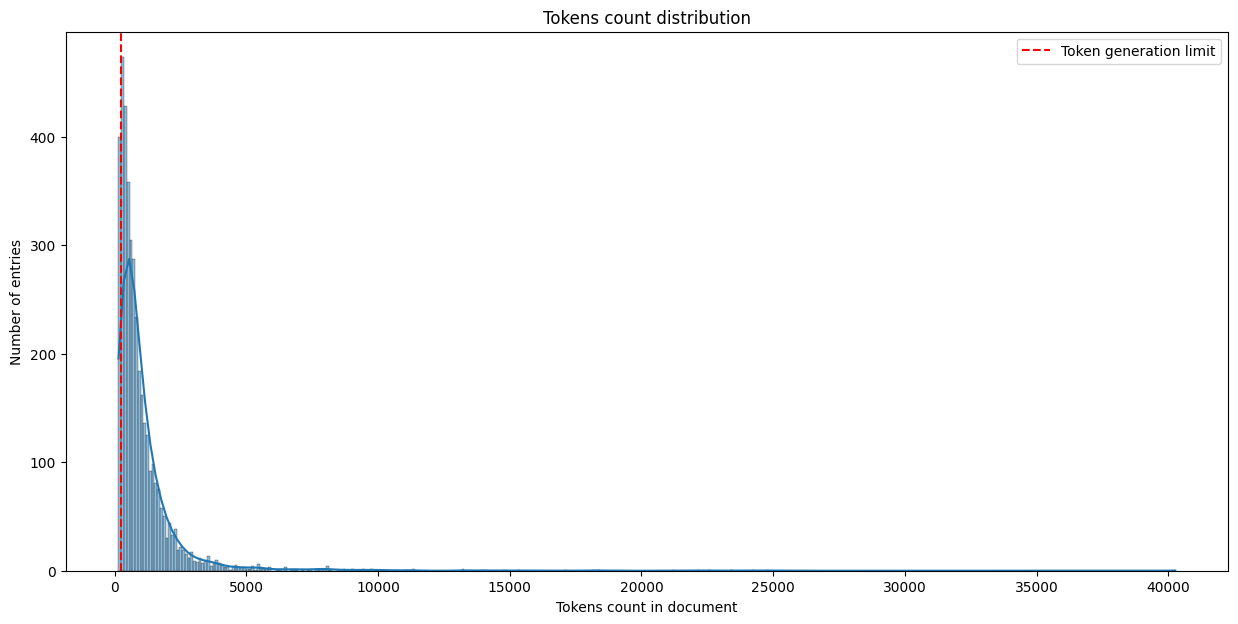

In [ ]:
tokens_count = [] # список под количество токенов в документах
for i in range(MAX_SAMPLES): # идём по документам
    data_tokenized = tokenizer(data["train"]["text"][i]) # токенизируем документы
    tokens_count.append(len(data_tokenized["input_ids"])) # запоминаем длину документа в токенах

# MAX_SEQUENCE_LEN = int(np.percentile(tokens_count, 95)) # оптимальное число токенов в документе считаем как перцентиль 95% (если не достаёт — padding, если перебор — truncation), определялось по гистограмме распределения числа токенов в текстах
print(f"The number of tokens generation is limited by the value {MAX_SEQUENCE_LEN}.")

plt.figure(figsize=(15,7)) # задание размера выводимой фигуры
plt.title("Tokens count distribution") # название графика
sns.histplot(data=tokens_count, kde=True) # построение гистограммы распределения количества токенов среди документов
plt.axvline(x=MAX_SEQUENCE_LEN, label="Token generation limit", color='r', linestyle='--') # ограничение количества генерируемых токенов 
plt.xlabel("Tokens count in document") # подпись по оси x
plt.ylabel("Number of entries") # подпись по оси y
plt.legend() # вывод подписей графиков
plt.show() # вывод графика

In [ ]:
def preprocess_function(data: Dataset) -> Dataset:
    """
    Функция для предобработки датасета.
    Parameters:
        data (Dataset) : Датасет для предобработки.
    Returns:
        Dataset: Предобработанный датасет.
    """
    model_input = tokenizer(data["text"], max_length=MAX_SEQUENCE_LEN, return_tensors="pt", padding=True, truncation=True) # токенизация с количеством токенов в MAX_SEQUENCE_LEN, с применением padding и truncation
    model_input["labels"] = model_input["input_ids"].clone() # таргеты для задачи Next Token Prediction совпадают с приходящими токенами (клонируем тензоры, даже без сдвига, так как Transformers внутри модели сами сместят их для расчета loss)
    return model_input

In [ ]:
data = data.map(preprocess_function, batched=True) # предобрабатываем датасет
data.set_format(type='torch', columns=["text", "input_ids", "attention_mask", "labels"]) # установка возвращаемого типа для метода __getitem__ всех Dataset в DatasetDict (чтобы он возвращал tensor объекты, а не обычные списки)
data = data["train"].train_test_split(test_size=TEST_SIZE, shuffle=True, seed=RANDOM_STATE) # разбиение датасета на тестовую и обучающую выборки
data

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 3600
    })
    test: Dataset({
        features: ['text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 400
    })
})

In [ ]:
BOLD_START = '\033[1m'
BOLD_END = '\033[0m'
for feature in data["train"].features:
    print(f"{BOLD_START}{feature}{BOLD_END}: {data['train'][feature][0]}") # пример сэмпла из датасета

text: The DPW’s Flaming Trebuchet at Burning Man 2015 was a Resto art piece which showed off our cleanup abilities. 6:37 was the time — that’s six minutes and thirty-seven seconds to clean up a flaming piano that’s been launched from a two-story slingshot and tossed splashing onto the ground like a fiery dirt clod.

The crew launched the trebuchet twice; both times, flaming piano cleanup took under seven minutes, leaving no trace.

We’ve all sort of grown up into semi-adults here together in Black Rock City. Many of us are decade-plus veterans of this sideshow. The DPW, much like Burning Man itself, usually takes its fresh managers from the herd.

Sure, especially now that the Org has become a non-profit, a few outside specialists have come on board, but as for the majority, a bunch of outsiders made this Burning Man thing and we’re going to keep running it until we individually graduate or collectively pass into the next level of the video game of life.

Here’s our family album from t

In [28]:
data.save_to_disk(DATA_DIR + DATASET_NAME + "_processed") # локальное сохранение датасета (в формате arrow)

Saving the dataset (0/1 shards):   0%|          | 0/7200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/800 [00:00<?, ? examples/s]

# 2) Дообучение моделей

## Подготовка к дообучению

In [ ]:
def train_preparation() -> tuple:
    """
    Функция для загрузки всего необходимого перед обучением.
    Returns:
        tuple: Кортеж загруженных объектов вида (данные, модель, токенизатор).
    """
    set_seed() # фиксирование seed_ов для воспроизводимости результатов

    data = load_from_disk(f"{DATA_DIR}{DATASET_NAME}_processed") # загрузка локально сохранённого датасета
    # data["train"] = data["train"].select(range(100))
    # data["test"] = data["test"].select(range(20))

    # config = LoraConfig(
    #     r=32, # ранг обучаемых матриц (чем ниже, тем меньше обучаемых параметров и меньше нагрузка на память)
    #     lora_alpha=64, # коэффициент масштабирования (обычно кратен r)
    #     target_modules="all-linear", # целевые слои для адаптеров ("all-linear" — все линейные слои)
    #     # init_lora_weights="gaussian", # как инициализируются веса LoRA матриц
    #     lora_dropout=0.05, # вероятность дропаута для предотвращения переобучения
    #     bias="none", # без смещения
    #     task_type="CAUSAL_LM" # тип задачи
    # )

    model = AutoModelForCausalLM.from_pretrained(f"{MODELS_DIR}{MODEL_NAME}") # загрузка модели
    
    # model = get_peft_model(model, config) # использование LoRA для fine-tuning_а (автоматически замораживает изначальные веса модели)
    # for name, param in model.named_parameters(): # идём по параметрам модели
    #     if "lora" in name: # если веса связаны с LoRA адаптером — обучаем их
    #         param.requires_grad = True
    #     else: # остальные веса замораживаем
    #         param.requires_grad = False # замораживаем веса модели (запрещаем им обучаться) 
    model.to(DEVICE) # отправка модели на device
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # загрузка токенизатора

    return data, model, tokenizer

In [ ]:
def clear_gpu_cache() -> None:
    """
    Функция для очистки использованной и более не зарезервированной памяти на GPU.
    """
    if "cuda" in str(DEVICE):
        torch.cuda.empty_cache() # очищение кэша GPU
        torch.cuda.memory.reset_peak_memory_stats() # обновляем (обнуляем) записи о максимальной использованной памяти

In [ ]:
def log_gpu_memory() -> tuple:
    """
    Функция для замера текущей загрузки GPU.
    Returns:
        tuple: Кортеж вида (выделенная_память, зарезервированная_память, максимальная_выделенная_память_за_период_подсчёта).
    """
    if "cuda" in str(DEVICE):
        allocated = torch.cuda.memory_allocated() / (1024 ** 3) # память в GB (делим на 1024 ** 3), занятая тензорами на GPU
        reserved = torch.cuda.memory_reserved() / (1024 ** 3) # память в GB (делим на 1024 ** 3), зарезервированная кэш-аллокатором PyTorch
        max_allocated = torch.cuda.max_memory_allocated() / (1024 ** 3) # пиковое значение выделенной памяти в GB (делим на 1024 ** 3) за все время работы
    else:
        allocated = 0
        reserved = 0
        max_allocated = 0

    return allocated, reserved, max_allocated

In [ ]:
def print_trainable_parameters(model):
    """
    Функция для вывода количества обучаемых параметров модели.
    Parameters:
        model (Any) : Обучаемая модель.
    """
    trainable_params = 0
    all_params = 0
    for param in model.parameters():
        all_params += param.numel() # суммируем количество значений во всех весовых матрицах
        if param.requires_grad:
            trainable_params += param.numel() # суммируем обучаемые веса
    print(f"trainable params: {trainable_params} || all params: {all_params} || trainable: {100 * trainable_params / all_params:.4f}%")

In [ ]:
def benchmark_model(model, benchmarks: list[str]) -> pd.DataFrame:
    """
    Функция для валидации модели на бенчмарках.
    Parameters:
        model (Any) : Тестируемая модель (path_to_model or model object).
        benchmarks (list[str]) : Список бенчмарков для теста. 
    Returns:
        pd.DataFrame: DataFrame с посчитанными метриками.
    """
    if isinstance(model, str): # если передан путь до модели
        model = AutoModelForCausalLM.from_pretrained(model).to(DEVICE) # загружаем модель из указанного пути и отправляем на девайс
    
    benchmarks = lm_eval.simple_evaluate( # валидация модели на выбранном бенчмарке
        model=HFLM(model), # модель для валидации (обёртка HFLM, если модель с Hugging Face)

        tasks=benchmarks, # названия тестируемых бенчмарков
        
        # batch_size="auto:4", # размер батча (auto:N — определяет автоматически максимальный размер батча, что помещается на устройство; N определяет, сколько раз нужно пересчитать максимальный размер батча (если среди данных есть примеры с разной размерностью))
        batch_size=BATCH_SIZE, # размер батча
        
        device=str(DEVICE), # на каком устройстве запускаться

        # фиксируем seed_ы для воспроизводимости результатов
        random_seed=RANDOM_STATE,
        numpy_random_seed=RANDOM_STATE,
        torch_random_seed=RANDOM_STATE,

        # уровень подробностей вывода (WARNING и INFO выводят много логов в терминал)
        verbosity="ERROR",
        # verbosity="WARNING",
        # verbosity="INFO",
    )["results"] # берём значение метрик бенчмарков

    return pd.DataFrame(benchmarks) # возвращение результатов в виде pd.DataFrame

In [ ]:
def train_model(model, optimizers, train_dataloader: DataLoader, test_dataloader: DataLoader, model_name: str, tracked_metric: str = "Test loss") -> dict:
    """
    Функция для обучения и валидации моделей, сохраняющая лучшую найденную модель по метрике tracked_metric и возвращающая логи обучения.
    Parameters:
        model (Any) : Обучаемая модель.
        optimizers (Any) : Список оптимизаторов весов модели.
        train_dataloader (DataLoader) : Loader для обучающих данных.
        test_dataloader (DataLoader) : Loader для тестовых данных.
        model_name (str) : Название сохраняемой модели.
        tracked_metric (str) : Отслеживаемая метрика для досрочного прерывания обучения (помимо сходимости весов).
    Returns:
        dict: Словарь с логами процесса обучения и валидации.
    """

    history = { # словарь для сохранения истории обучения
        "Hyperparams": hyperparams, # гиперпараметры обучения
        "Train loss": {}, # значение loss функции при обучении
        "Test loss": {}, # значение loss функции при валидации
        "Weight convergence": {}, # метрика сходимости весов модели
        "Time start": None, # время начала обучения
        "Time end": None, # время окончания обучения
        "Time epoch": {}, # время обучения на эпохах
        "GPU memory": {}, # статистика используемой памяти (перед началом обучения, во время обучения и после)
        "Learning rate": {}, # learning rate на эпохах обучения 
        "Train benchmarks": {}, # значения метрик на бенчмарках
        "AVG benchmarks acc": {}, # усреднённая точность на бенчмарках 
        "Tracked metric": tracked_metric, # отслеживаемая метрика
    } 

    
    print("Starting training with hyperparams:")
    for key, param in hyperparams.items():
        print(f"{key}: {param}")

    
    schedulers = [lr_scheduler.StepLR(optimizer, step_size=SCHEDULER_STEP, gamma=SCHEDULER_GAMMA) for optimizer in optimizers] # sheduler_ы для обновления learning rate оптимизаторов весов

    
    clear_gpu_cache() # очистка кэша и обновление мониторов памяти
    history["GPU memory"]["init"] = log_gpu_memory() # замеряем используемую GPU память перед началом обучения


    # замер метрик перед обучением
    model.eval() # переводим модель в режим валидации
    with torch.no_grad(): # без подсчёта градиентов
        # loss на обучающей части
        loss_train_total = 0 # loss на обучении
        for batch in tqdm(train_dataloader): # идём по батчам
            input_ids = batch["input_ids"].to(DEVICE) # отправка данных на девайс
            outputs = model(input_ids=input_ids, labels=input_ids) # генерируем объект предсказаний (при передаче ещё и labels, модель возвращает CausalLMOutputWithCrossAttentions объект, содержащий как предсказания, так и значение loss функции)
            loss_train = outputs.loss # значение loss функции (раньше для этого использовалась отдельная функция, например, torch.nn.CrossEntropyLoss)
            
            loss_train_total += loss_train.item() # суммируем loss по батчам из loader объекта
        loss_train_avg = loss_train_total / len(train_dataloader) # средний loss при обучении

        # loss на тесте
        loss_test_total = 0 # loss на валидации
        for batch in tqdm(test_dataloader): # идём по батчам
            input_ids = batch["input_ids"].to(DEVICE) # отправка данных на девайс
            outputs = model(input_ids=input_ids, labels=input_ids) # генерируем объект предсказаний (при передаче ещё и labels, модель возвращает CausalLMOutputWithCrossAttentions объект, содержащий как предсказания, так и значение loss функции)
            loss_test = outputs.loss # значение loss функции (раньше для этого использовалась отдельная функция, например, torch.nn.CrossEntropyLoss)
            
            loss_test_total += loss_test.item() # суммируем loss по батчам из loader объекта
        loss_test_avg = loss_test_total / len(test_dataloader) # средний loss при валидации

        # валидация на бенчмарках
        if len(EVAL_BENCHMARKS_TRAINING) > 0: # если есть тестируемые бенчмарки
            history["Train benchmarks"]["init"] = benchmark_model(model, EVAL_BENCHMARKS_TRAINING) # логирование метрик на бенчмарках
            history["AVG benchmarks acc"]["init"] = history["Train benchmarks"]["init"].loc["acc,none"].mean().item() # средний accuracy на бенчмарках 
        else: # иначе — не считаем бенчмарки
            history["Train benchmarks"]["init"] = None
            history["AVG benchmarks acc"]["init"] = 0
    history["Train loss"]["init"] = loss_train_avg
    history["Test loss"]["init"] = loss_test_avg
    print(f"Initial metrics:\n Average train Loss: {loss_train_avg:.4f}, Average test Loss: {loss_test_avg:.4f}, Tracked metric ({tracked_metric}): {history[tracked_metric]['init']:.6f}.")

    
    epochs_without_improve = 0 # счётчик количества эпох без улучшения отслеживаемой метрики
    last_best_metric = -float("inf") # последнее лучшее значение отслеживаемой метрики
    previous_weights = [param.clone() for param in model.parameters() if param.requires_grad] # значение весов модели на прошлом шаге (для отслеживания сходимости)

    
    time_start = time.time() # время старта обучения
    for epoch in range(EPOCHS):
        clear_gpu_cache() # очистка кэша и обновление мониторов памяти
        
        # обучение
        model.train() # перевод модели в режим обучения
        time_start_epoch = time.time() # время начала эпохи обучения
        loss_train_total = 0 # loss на обучении
        for batch in tqdm(train_dataloader): # идём по батчам
            for optimizer in optimizers: # для каждого оптимизатора
                optimizer.zero_grad() # обнуление старых градиентов весов модели
            
            input_ids = batch["input_ids"].to(DEVICE) # отправка данных на девайс

            outputs = model(input_ids=input_ids, labels=input_ids) # генерируем объект предсказаний (при передаче ещё и labels, модель возвращает CausalLMOutputWithCrossAttentions объект, содержащий как предсказания, так и значение loss функции)
            loss_train = outputs.loss # значение loss функции (раньше для этого использовалась отдельная функция, например, torch.nn.CrossEntropyLoss)

            loss_train.backward() # запуск процесса обратного распространения ошибки (вычисление градиента для весов модели)
            for optimizer in optimizers: # для каждого оптимизатора
                optimizer.step() # обновление весов модели в соответствии с вычисленными градиентами
            
            loss_train_total += loss_train.item() # суммируем loss по батчам из loader объекта
        loss_train_avg = loss_train_total / len(train_dataloader) # средний loss при обучении

        
        current_lr = np.mean([optimizer.param_groups[0]["lr"] for optimizer in optimizers]).item() # средний learning rate среди оптимизаторов
        for scheduler in schedulers: # делаем шаг планировщиков learning rate после эпохи обучения
            scheduler.step()

        
        history["Time epoch"][epoch + 1] = time.time() - time_start_epoch # время, которое было затрачено на эпоху обучения
        history["GPU memory"][epoch + 1] = log_gpu_memory() # память после эпохи обучения
        history["Learning rate"][epoch + 1] = current_lr # learning rate на текущей итерации

        
        # оценка модели
        model.eval() # переводим модель в режим валидации
        loss_test_total = 0 # loss на валидации
        with torch.no_grad(): # без подсчёта градиентов
            # loss на тесте
            for batch in tqdm(test_dataloader): # идём по батчам
                input_ids = batch["input_ids"].to(DEVICE) # отправка данных на девайс
                outputs = model(input_ids=input_ids, labels=input_ids) # генерируем объект предсказаний (при передаче ещё и labels, модель возвращает CausalLMOutputWithCrossAttentions объект, содержащий как предсказания, так и значение loss функции)
                loss_test = outputs.loss # значение loss функции (раньше для этого использовалась отдельная функция, например, torch.nn.CrossEntropyLoss)
                
                loss_test_total += loss_test.item() # суммируем loss по батчам из loader объекта
            loss_test_avg = loss_test_total / len(test_dataloader) # средний loss при валидации


            # отслеживание сходимости весов
            current_weights = [param for param in model.parameters() if param.requires_grad] # текущие значения обучаемых параметров модели
            weight_change = sum(torch.norm(curr_param - prev_param, p=2).item() for curr_param, prev_param in zip(current_weights, previous_weights)) # изменение обучаемых весов за эпоху (L2 норма)
            previous_weights = [param.clone() for param in model.parameters() if param.requires_grad] # сохранение текущих весов


            # валидация на бенчмарках
            if len(EVAL_BENCHMARKS_TRAINING) > 0: # если есть тестируемые бенчмарки
                history["Train benchmarks"][epoch + 1] = benchmark_model(model, EVAL_BENCHMARKS_TRAINING) # логирование метрик на бенчмарках
                history["AVG benchmarks acc"][epoch + 1] = history["Train benchmarks"][epoch + 1].loc["acc,none"].mean().item() # средний accuracy на бенчмарках 
            else: # иначе — не считаем бенчмарки
                history["Train benchmarks"][epoch + 1] = None
                history["AVG benchmarks acc"][epoch + 1] = 0
                
        
        history["Train loss"][epoch + 1] = loss_train_avg
        history["Test loss"][epoch + 1] = loss_test_avg
        history["Weight convergence"][epoch + 1] = weight_change


        # вывод информации о процессе обучения
        if (epoch + 1) % VERBOSE == 0: # выводим информацию л процессу обучения
            print(f"Epoch [{epoch + 1}/{EPOCHS}], Average train Loss: {loss_train_avg:.4f}, Average test Loss: {loss_test_avg:.4f}, Tracked metric ({tracked_metric}): {history[tracked_metric][epoch + 1]:.6f}, Learning rate: {current_lr:.8f}, Weight change: {weight_change:.6f}.")

        
        # досрочное прерывание и сохранение лучшей модели (по отслеживаемой метрике)
        patience_reduced = False # флаг, было ли уменьшено количество эпох терпимости 
        if history[tracked_metric][epoch + 1] > last_best_metric: # если есть улучшение метрики — сохраняем модель
            last_best_metric = history[tracked_metric][epoch + 1] # обновление отслеживаемой метрики
            epochs_without_improve = 0 # обнуление счётчика эпох без улучшения
            model.save_pretrained(f"{MODELS_DIR}{model_name}", from_pt=True) # сохранение модели
            tokenizer.save_pretrained(f"{MODELS_DIR}{model_name}") # сохранение токенизатора
        elif epochs_without_improve < EPOCHS_PATIENCE: # увеличиваем счётчик, если не было улучшения 
            epochs_without_improve += 1
            patience_reduced = True 
        else: 
            print(f"Early stopping at epoch {epoch + 1}, tracked metric: {history[tracked_metric][epoch + 1]:.6f}!")
            break # выходим из цикла обучения

        # досрочное прерывание (по сходимости весов ~ ускоряет прерывание по отслеживаемой метрике, если изменение весов не велико)
        if not patience_reduced: # если на шаге ещё не было уменьшено количество эпох терпимости
            if weight_change < TOLERANCE: # если изменение весов незначительное
                if epochs_without_improve < EPOCHS_PATIENCE: # увеличиваем счётчик, если ещё не исчерпаны эпохи терпения
                    epochs_without_improve += 1
                else: # иначе — выходим из цикла обучения
                    print(f"Early stopping at epoch {epoch + 1}, weight change: {weight_change:.6f}!")
                    break
            else: 
                epochs_without_improve = 0 # обнуление счётчика эпох без улучшения


    time_end = time.time() # время окончания обучения
    clear_gpu_cache() # очистка кэша и обновление мониторов памяти
    history["Time start"], history["Time end"] = time_start, time_end
    history["GPU memory"]["end"] = log_gpu_memory() # замеряем используемую GPU память после обучения
    print(f"Total training time: {time_end - time_start:.2f} sec ~ {(time_end - time_start) / 60**2:.2f} hours.")

    return history

In [35]:
def save_history(history, model_name) -> None:
    """
    Функция для сохранения истории обучения.
    Parameters:
        history (dict) : Словарь с замеренными метриками.
        model_name (str) : Название обученной модели (в какую подпапку сохранять результаты).
    """
    os.makedirs(f"{RESULTS_DIR}{model_name}/", exist_ok=True) # создание папки
    with open(f"{RESULTS_DIR}{model_name}/history.pkl", 'wb') as file: # открытие файла для записи ('wb' — бинарной)
        pickle.dump(history, file) # сохранение в файл

In [36]:
def plot_history(history: dict) -> None:
    """
    Функция для визуализации замеряемых метрик при обучении.
    Parameters:
        history (dict) : Словарь с замеренными метриками.
    """
    history_df = pd.DataFrame({metric: history[metric] for metric in ["Train loss", "Test loss", "AVG benchmarks acc", "Weight convergence", "Learning rate", "Time epoch", "GPU memory"]}) # конвертация словаря в DataFrame

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,16)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

    # берём данные об обучении
    epochs_main = list(history_df[history_df["Test loss"].notna()].index) # эпохи для метрик, отслеживаемых до и во время обучения ("init" и номера эпох)
    loss_train = history_df["Train loss"][epochs_main].values # значение loss при обучении
    loss_test = history_df["Test loss"][epochs_main].values # значение loss при тесте
    avg_acc = history_df["AVG benchmarks acc"][epochs_main].values # среднее значение Accuracy на бенчмарках

    epochs_misc = list(history_df[history_df["Learning rate"].notna()].index) # эпохи для метрик, отслеживаемых только при обучении (номера эпох)
    weight_change = history_df["Weight convergence"][epochs_misc].values # изменение весов по эпохам
    learning_rate = history_df["Learning rate"][epochs_misc].values # изменение learning rate по эпохам
    train_time = history_df["Time epoch"][epochs_misc].values # время обучения на каждой эпохе

    epochs_full =  list(history_df[history_df["GPU memory"].notna()].index) # эпохи для метрик, отслеживаемых до, во время и после обучения ("init", номера эпох, "end")
    gpu_memory = np.array(list(history_df["GPU memory"][epochs_full].values)) # изменение потребляемой памяти по эпохам

    # best_epoch = avg_acc.argmax() + 1 # эпоха с наилучшей метрикой (+1 из-за нумерации в array с 0)
    best_epoch = history_df[history["Tracked metric"]].idxmax() # эпоха с наилучшей метрикой

    axes[0][0].plot(epochs_main, loss_train, color="b", label="Train") # построение графика
    axes[0][0].plot(epochs_main, loss_test, color="r", label="Test") # построение графика
    axes[0][0].axvline(x=best_epoch, label="Best (saved) model", color='g', linestyle='--') # построение графика
    # axes[0][0].set_xticklabels(axes[0][0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[0][0].set_title("Changing of the loss function (Cross-Entropy)") # название фигуры
    axes[0][0].set_xlabel("Epoch") # подпись по оси OX
    axes[0][0].set_ylabel("Loss") # подпись по оси OY
    # axes[0][0].set_ylim([0, 3]) # лимит вывода шкалы
    axes[0][0].grid(True) # отображение сетки на графике
    axes[0][0].legend() # отображение подписей графиков

    axes[0][1].plot(epochs_main, avg_acc, color="r", label="Validation") # построение графика
    axes[0][1].plot(best_epoch, history_df["AVG benchmarks acc"][best_epoch], 'o', color="g", label="Best (saved) model") # выводим точку, где была найдена лучшая модель
    # axes[0][1].set_xticklabels(axes[0][1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[0][1].set_title("Changing of average accuracy on benchmarks") # название фигуры
    axes[0][1].set_xlabel("Epoch") # подпись по оси OX
    axes[0][1].set_ylabel("Accuracy") # подпись по оси OY
    axes[0][1].grid(True) # отображение сетки на графике
    axes[0][1].legend() # отображение подписей графиков

    axes[1][0].plot(epochs_misc, weight_change, color="b", label="Weights change") # построение графика
    # axes[1][0].set_xticklabels(axes[1][0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[1][0].set_title("Changing of model's weight L2-norm") # название фигуры
    axes[1][0].set_xlabel("Epoch") # подпись по оси OX
    axes[1][0].set_ylabel("Weight change (L2-norm)") # подпись по оси OY
    axes[1][0].grid(True) # отображение сетки на графике
    axes[1][0].legend() # отображение подписей графиков

    axes[1][1].plot(epochs_misc, learning_rate, color="b", label="Learning rate") # построение графика
    # axes[1][1].set_xticklabels(axes[1][1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[1][1].set_title("Changing of learning rate during training") # название фигуры
    axes[1][1].set_xlabel("Epoch") # подпись по оси OX
    axes[1][1].set_ylabel("Learning rate") # подпись по оси OY
    axes[1][1].grid(True) # отображение сетки на графике
    axes[1][1].legend() # отображение подписей графиков

    axes[2][0].plot(epochs_misc, train_time, color="r", label="Training time") # построение графика
    # axes[2][0].set_xticklabels(axes[2][0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[2][0].set_title("Training time of each epoch (validation excluded)") # название фигуры
    axes[2][0].set_xlabel("Epoch") # подпись по оси OX
    axes[2][0].set_ylabel("Time (sec)") # подпись по оси OY
    axes[2][0].grid(True) # отображение сетки на графике
    axes[2][0].legend() # отображение подписей графиков

    axes[2][1].plot(epochs_full, gpu_memory[:, 0], color="b", label="Allocated") # построение графика
    axes[2][1].plot(epochs_full, gpu_memory[:, 1], color="y", label="Reserved") # построение графика
    axes[2][1].plot(epochs_full, gpu_memory[:, 2], color="r", label="Max allocated") # построение графика
    # axes[2][1].set_xticklabels(axes[2][1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
    axes[2][1].set_title("GPU memory usage by epoch") # название фигуры
    axes[2][1].set_xlabel("Epoch") # подпись по оси OX
    axes[2][1].set_ylabel("GPU memory, GB") # подпись по оси OY
    axes[2][1].grid(True) # отображение сетки на графике
    axes[2][1].legend() # отображение подписей графиков

    plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
    plt.show() # показ фигуры

## AdamW

Оптимизатор **Adam** (Adaptive Moment Estimation) — алгоритм оптимизации весов нейронных сетей, основывающийся на обратном распространении ошибки (градиенте) и сочетающий в себе идеи из AdaGrad (***Momentum***) и RMSProp (***индивидуальная скорость обучения для каждого параметра***). *Алгоритм хранит в памяти два значения **для каждого обучаемого параметра** модели*:
1. Первый момент (aka скользящее среднее градиента, $m_t$) — аналог инерции (Momentum), что помогает не застревать в локальных минимумах.
2. Второй момент (aka скользящее среднее квадрата градиента, $v_t$) — аналог адаптивной скорости, помогает уменьшать шаг там, где градиенты очень резкие, и увеличивать там, где они пологие.

Эта комбинация позволяет оптимизатору делать более крупные шаги на ровных участках ландшафта и более мелкие, осторожные шаги на крутых или «шумных» участках.

***Алгоритм Adam*** состоит из следующих шагов (на каждой итерации $t$ для каждого параметра $\theta$ выполняются следующие вычисления):

0) Изначально, при $t=0$, $m_t$ (или $m_0$) и $v_t$ (или $v_0$) для весовых матриц равны нулю.
1) Вычисляется градиент $g_t$ (производная функции потерь по текущему весу $\theta$) по формуле:
    * $g_t = ∇_{\theta}L(\theta_t)$

    **Если ещё применяется L2-регуляризация** ($\lambda$ — коэффициент регуляризации, weight decay), то градиент $g_t$ считается как:
    * $g_t = ∇_{\theta}L(\theta_t) + \lambda \cdot \theta_{t-1}$
2) Обновляются моменты (с применением экспоненциального затухания ~ чтобы «старые» градиенты забывались, а «новые» имели больший вес):
    * $m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$
    * $v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$ 

    $\beta_1$ (обычно 0.9) определяет, насколько сильно мы доверяем прошлому опыту. $\beta_2$ (обычно 0.999) отвечает за «память» о волатильности градиента.
3) Корректируется смещение (Bias Correction). Из-за того, что в самом начале обучения $m_t$ и $v_t$ равны 0 — они долго «разгоняются» и тяготеют к нулю. Чтобы это исправить, их масштабируют (благодаря чему при малых $t>0$ их значения в разы больше, чем должно быть, но при увеличении $t$, $\beta^t$ уменьшаются, а следовательно и коэффициент масштабирования стремится к 1):
    * $\hat{m}_t = \frac{m_t}{1-\beta_1^t}$
    * $\hat{v}_t = \frac{v_t}{1-\beta_2^t}$
4) После масштабирования идёт этап обновления весов модели ($η$ — learning rate, $\epsilon$ — минимальная добавка, чтобы в знаменателе не было нуля):
    * $\theta_{t+1} = \theta_t - η \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

***Отличие же AdamW от Adam заключается в месте применения L2 регуляризации*** (weight decay). Когда стандартный Adam применяет регуляризацию непосредственно к градиентам (см. шаг 1 вычисления, что может привести к нежелательным эффектам), ***AdamW делает это отдельно, на уровне обновления параметров***, а не на уровне градиентов. Таким образом, AdamW более точно реализует концепцию weight decay, что может привести к лучшим результатам в обучении. Другими словами, у AdamW добавляется дополнительный шаг (заменяющий момент с L2-регуляризацией).

***Алгоритм AdamW:***

0) Изначально, при $t=0$, $m_t$ (или $m_0$) и $v_t$ (или $v_0$) для весовых матриц равны нулю.
1) Вычисляется градиент $g_t$ (производная функции потерь по текущему весу $\theta$) по формуле:
    * $g_t = ∇_{\theta}L(\theta_t)$
2) Обновляются моменты (с применением экспоненциального затухания ~ чтобы «старые» градиенты забывались, а «новые» имели больший вес):
    * $m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t$
    * $v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2$ 

    $\beta_1$ (обычно 0.9) определяет, насколько сильно мы доверяем прошлому опыту. $\beta_2$ (обычно 0.999) отвечает за «память» о волатильности градиента.
3) Корректируется смещение (Bias Correction). Из-за того, что в самом начале обучения $m_t$ и $v_t$ равны 0 — они долго «разгоняются» и тяготеют к нулю. Чтобы это исправить, их масштабируют (благодаря чему при малых $t>0$ их значения в разы больше, чем должно быть, но при увеличении $t$, $\beta^t$ уменьшаются, а следовательно и коэффициент масштабирования стремится к 1):
    * $\hat{m}_t = \frac{m_t}{1-\beta_1^t}$
    * $\hat{v}_t = \frac{v_t}{1-\beta_2^t}$
4) **Применяется регуляризация к весам** $\theta$ ($\lambda$ — коэффициент регуляризации, weight decay):
    * $\theta_{t+1} = \theta_{t} - η \cdot \lambda \cdot \theta_{t}$
5) Этап обновления весов модели ($η$ — learning rate, $\epsilon$ — минимальная добавка, чтобы в знаменателе не было нуля):
    * $\theta_{t+1} = \theta_{t+1} - η \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

    Шаги 4 и 5 можно перезаписать в следующем виде:
    * $\theta_{t+1} = \theta_{t} - η \cdot \lambda \cdot \theta_{t} - η \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} = \theta_{t} - η \cdot \left(\lambda \cdot \theta_{t} + \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}\right)$

![Adam steps](./images/Adam_formula.png) 
![AdamW steps](./images/AdamW_formula.png)

Плюсы оптимизатора AdamW:
* Каждый параметр получает свой эффективный Learning Rate.
* Благодаря инерции ($m_t$), алгоритм меньше «виляет» на шумных данных.
* Adam обычно сходится быстрее, чем обычный SGD, и менее чувствителен к начальной настройке скорости обучения.
* Adam почти всегда работает «из коробки» с дефолтными гиперпараметрами.

In [ ]:
model_name = f"{MODEL_NAME}_AdamW" # название модели для сохранения

In [ ]:
data, model, tokenizer = train_preparation() # загружаем всё необходимое перед обучением

train_dataloader = DataLoader(data["train"], batch_size=BATCH_SIZE, shuffle=True) # DataLoader для итерации в цикле обучения
test_dataloader = DataLoader(data["test"], batch_size=BATCH_SIZE) # DataLoader для итерации в цикле обучения

clear_gpu_cache() # очистка кэша и обновление мониторов памяти
model

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [ ]:
adamw_params = [param for param in model.parameters() if param.requires_grad] # параметры для обучения


optimizer_adamw = torch.optim.AdamW(
    adamw_params,
    lr=LEARNING_RATE, 
    betas=(0.9, 0.95), # beta1 — Momentum, коэффициент инерции (отвечает за усреднение градиентов, помогает «разгоняться» в нужном направлении и сглаживать резкие колебания и шум; 0.9 означает, что текущий шаг на 90% зависит от предыдущего направления и на 10% от нового градиента), beta2 — RMSProp, адаптивная скорость обучения («нормирует» шаги: если градиент по какому-то весу очень большой и шумный, beta2 помогает уменьшить скорость обучения для этого веса, чтобы обучение не «взорвалось»), то есть beta1 усредняет направление движения, а beta2 — масштаб (интенсивность) этого движения для каждого параметра отдельно
    weight_decay=WEIGHT_DECAY, # коэффициент затухания весов (регуляризация против переобучения)
    eps=1e-08, # число для предотвращения деления на ноль
) # оптимизатор обучения модели

In [ ]:
print_trainable_parameters(model) # обучаемые параметры

trainable params: 494032768 || all params: 494032768 || trainable%: 100.0


In [ ]:
history = train_model(model, [optimizer_adamw], train_dataloader, test_dataloader, model_name, "AVG benchmarks acc") # обучение модели
save_history(history, model_name) # сохранение истории
history

Starting training with hyperparams:
WORKING_DIR: /kaggle/working/
DATA_DIR: /kaggle/working/data/
MODELS_DIR: /kaggle/working/models/
RESULTS_DIR: /kaggle/working/results/
DATASET_NAME: Elriggs/openwebtext-100k
MODEL_NAME: Qwen/Qwen2.5-0.5B
EVAL_BENCHMARKS_TRAINING: ['piqa', 'winogrande']
EVAL_BENCHMARKS: ['piqa', 'arc_easy', 'arc_challenge', 'winogrande', 'hellaswag']
MAX_SAMPLES: 4000
MAX_SEQUENCE_LEN: 256
TEST_SIZE: 0.1
EPOCHS: 20
EPOCHS_PATIENCE: 3
TOLERANCE: 1
LEARNING_RATE: 2e-05
WEIGHT_DECAY: 0.1
SCHEDULER_STEP: 4
SCHEDULER_GAMMA: 0.5
BATCH_SIZE: 4
VERBOSE: 1
RANDOM_STATE: 42
DEVICE: cuda:0


  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration


piqa_train.parquet:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

...

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Running loglikelihood requests: 100%|██████████| 6210/6210 [05:44<00:00, 18.02it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


Epoch [5/20], Average train Loss: 1.9133, Average test Loss: 3.3734, Tracked metric (AVG benchmarks acc): 0.617727, Learning rate: 0.00001000, Weight change: 14.731662.
Early stopping at epoch 5, tracked metric: 0.617727!
Total training time: 9002.47 sec ~ 2.50 hours.


{'Hyperparams': {'WORKING_DIR': '/kaggle/working/',
  'DATA_DIR': '/kaggle/working/data/',
  'MODELS_DIR': '/kaggle/working/models/',
  'RESULTS_DIR': '/kaggle/working/results/',
  'DATASET_NAME': 'Elriggs/openwebtext-100k',
  'MODEL_NAME': 'Qwen/Qwen2.5-0.5B',
  'EVAL_BENCHMARKS_TRAINING': ['piqa', 'winogrande'],
  'EVAL_BENCHMARKS': ['piqa',
   'arc_easy',
   'arc_challenge',
   'winogrande',
   'hellaswag'],
  'MAX_SAMPLES': 4000,
  'MAX_SEQUENCE_LEN': 256,
  'TEST_SIZE': 0.1,
  'EPOCHS': 20,
  'EPOCHS_PATIENCE': 3,
  'TOLERANCE': 1,
  'LEARNING_RATE': 2e-05,
  'WEIGHT_DECAY': 0.1,
  'SCHEDULER_STEP': 4,
  'SCHEDULER_GAMMA': 0.5,
  'BATCH_SIZE': 4,
  'VERBOSE': 1,
  'RANDOM_STATE': 42,
  'DEVICE': device(type='cuda', index=0)},
 'Train loss': {'init': 3.2488166513707903,
  1: 2.929755965338813,
  2: 2.6784920590453676,
  3: 2.442833602958255,
  4: 2.2017965296904247,
  5: 1.91332811249627},
 'Test loss': {'init': 3.2672068452835084,
  1: 2.931557035446167,
  2: 2.972764356136322,
  

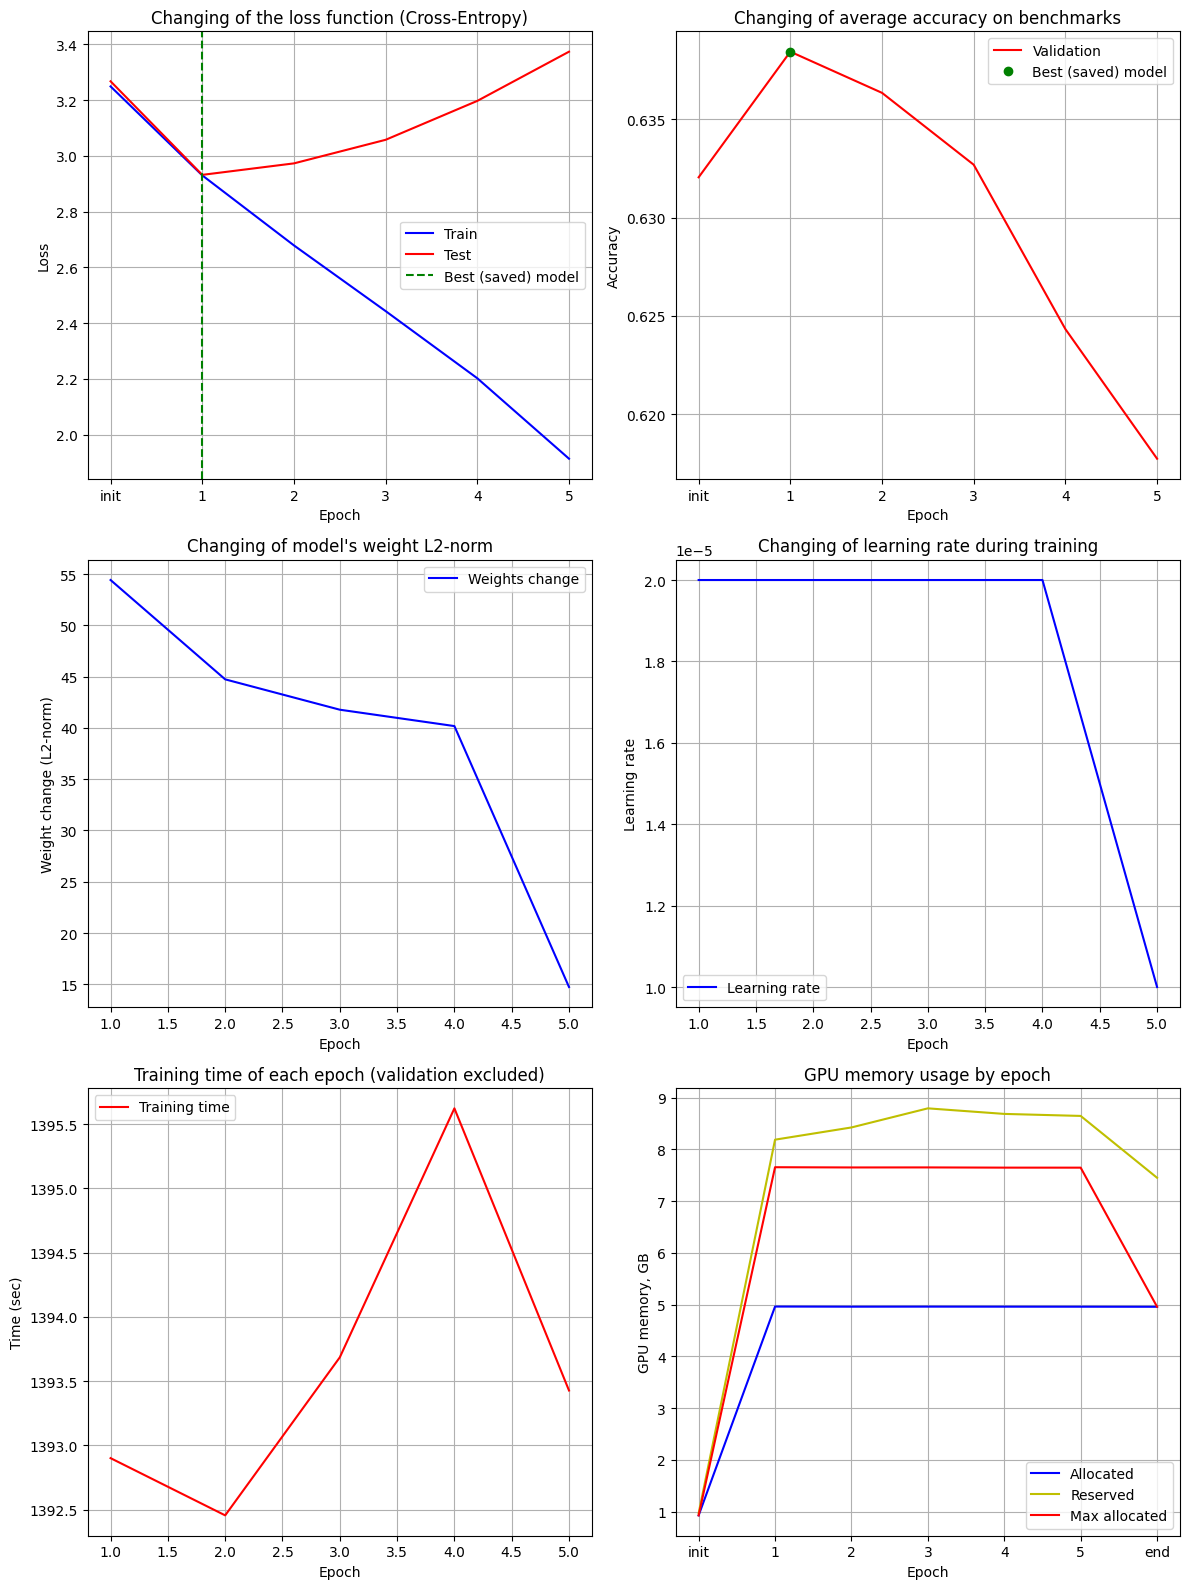

In [ ]:
plot_history(history)

In [ ]:
history["Test benchmarks"] = benchmark_model(f"{MODELS_DIR}{model_name}", EVAL_BENCHMARKS) # тестирование на всех бенчмарках сохранённой (лучшей) модели
save_history(history, model_name) # перезапись сохранённой истории (с результатами валидации)
history["Test benchmarks"]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

Map:   0%|          | 0/39905 [00:00<?, ? examples/s]

Map:   0%|          | 0/10042 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 60566/60566 [1:05:08<00:00, 15.49it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


,arc_challenge,arc_easy,hellaswag,piqa,winogrande
alias,arc_challenge,arc_easy,hellaswag,piqa,winogrande
"acc,none",0.298635,0.659512,0.401514,0.707835,0.569061
"acc_stderr,none",0.013374,0.009724,0.004892,0.01061,0.013918
"acc_norm,none",0.340444,0.648569,0.516531,0.695321,NaN
"acc_norm_stderr,none",0.013847,0.009796,0.004987,0.010739,NaN


## Muon

Оптимизатор **Muon** (Momentum Updated Orthogonalized Optimizer) — алгоритм оптимизации весов нейронных сетей, основывающийся на ортогонализации градиентов (приведении матрицы градиента к ортогональному виду, где каждый столбец и строка ортогональная (перпендикулярны) друг другу и имеют длину 1). Если стандартные оптимизаторы вроде Adam адаптируют шаг для каждого веса отдельно (используя скользящее среднее квадрата градиента), то Muon работает с целыми матрицами параметров, стремясь сделать их «максимально информативными», без дублирования информации и сохраняя спектральные свойства матриц весов.

**Принцип работы**: 
Обычные градиенты часто содержат избыточность, из-за которой многие направления в пространстве весов обновляются почти одинаково. Muon применяет к матрице градиентов операцию, которая делает её ортогональной (или приближенно ортогональной). Также Muon, как и Adam, использует Momentum ($m_t$, скользящее среднее градиента), что помогает не застревать в локальных минимумах. Но, в отличие от Adam, Muon не хранит скользящее среднее квадратов градиента для адаптации шага, что снижает его требование к памяти.

***Алгоритм Muon:***

0) Изначально, при $t=0$, Momentum $m_t$ (или $m_0$) весовых матриц равны нулю.
1) Вычисляется градиент $g_t$ (производная функции потерь по текущему весу $\theta$) по формуле:
    * $g_t = ∇_{\theta}L(\theta_t)$
2) Считается Momentum (иначе, чем в Adam), что позволяет сгладить шум и сохранить инерцию движения к минимуму функции потерь (коэффициент $μ$, в Adam это $\beta_1$ ~ насколько сильно мы доверяем прошлому опыту):
    * $m_t = μ \cdot m_{t-1} + g_t$

    Если же применять Momentum Нестерова, то:
    * $m_t = μ^2 \cdot m_{t-1} + (1 + μ) \cdot g_t$
3) Производится ортогонализация матрицы градиентов $O_t$, для чего Muon берет матрицу накопленных градиентов и применяет к ней итерационную процедуру Ньютона-Шульца для получения аппроксимации (вместо классического SVD-разложения, которое вычислительно дорого): 
    * $O_t = NS_k^{(a,b,c)}(m_t; \epsilon)$
    
    Здесь $(a,b,c)$ — коэффициенты полинома ортогонализации Ньютона-Шульца, $\epsilon$ — минимальная добавка, чтобы в знаменателе не было нуля.
    
    Благодаря этому произведение матрицы на себя $OO^T \approx 1$, все сингулярные значения матрицы становятся равными 1, что убирает проблему разного масштаба градиентов для разных слоёв и параметров.
4) **Применяется L2 регуляризация к весам** ($\lambda$ — коэффициент регуляризации или weight decay, $η$ — изначальный learning rate):
    * $\theta_{t+1} = \theta_{t} - η \cdot \lambda \cdot \theta_{t}$
5) Пересчёт шага обновления $η$ (learning rate) в зависимости о размерности весовой матрицы (чтобы ортогонализованное обновление имело согласованное среднеквадратичное значение (RMS) для прямоугольных матриц) и учёт ортогональной матрицы градиента для обновления весов:
    * $η = AdjustLR(η; shape(\theta_t))$
    * $\theta_{t+1} = \theta_{t+1} - η \cdot O_t$

    Шаги 4 и 5 можно перезаписать в следующем виде:
    * $\theta_{t+1} = \theta_{t} - η \cdot \lambda \cdot \theta_{t} - AdjustLR(η; shape(\theta_t)) \cdot O_t$

![Muon steps](./images/Muon_formula.png)

Плюсы оптимизатора Muon:
* Выравнивает масштаб обновления по всем сингулярным направлениям (Muon заставляет все направления в пространстве весов обучаться с одинаковой скоростью, тогда как в Adam некоторые направления могут «затухать» быстрее других).
* Ускоряет сходимость, так как оптимизатор не тратит время на «раскачку» в узких каньонах функции потерь.
* Позволяет использовать более высокий темп обучения (learning rate) без потери стабильности.
* Требует меньше памяти, так как хранит только одно скользящее среднее (для Momentum) вместо двух.

Muon предназначен специально для ***двумерных весовых матриц*** (линейных слоев), в то время как для остальных параметров (embedding, нормализация, bias) обычно используется AdamW.

In [ ]:
model_name = f"{MODEL_NAME}_Muon" # название модели для сохранения

In [ ]:
data, model, tokenizer = train_preparation() # загружаем всё необходимое перед обучением

train_dataloader = DataLoader(data["train"], batch_size=BATCH_SIZE, shuffle=True) # DataLoader для итерации в цикле обучения
test_dataloader = DataLoader(data["test"], batch_size=BATCH_SIZE) # DataLoader для итерации в цикле обучения

clear_gpu_cache() # очистка кэша и обновление мониторов памяти

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
muon_params = [] # параметры для Muon оптимизатора
for name, param in model.named_parameters(): # идём по параметрам модели
    if (param.ndim == 2) and ("embed" not in name): # условие для матриц весов (только 2d матрицы)
        muon_params.append(param)
    else: # если веса не пойдут в оптимизатор, то они не требуют градиент
        param.requires_grad = False # замораживаем веса модели (запрещаем им обучаться) 


optimizer_muon = torch.optim.Muon(
    muon_params, 
    lr=LEARNING_RATE, 
    adjust_lr_fn="match_rms_adamw", # регулировка learning rate для ускорения обучения ("original" или "match_rms_adamw", для чистоты эксперимента выбран "match_rms_adamw", так как иначе веса обновляются очень слабо по сравнению с AdamW при аналогичном lr)
    momentum=0.9, # коэффициент инерции (отвечает за усреднение градиентов, помогает «разгоняться» в нужном направлении и сглаживать резкие колебания и шум; 0.9 означает, что текущий шаг на 90% зависит от предыдущего направления и на 10% от нового градиента) 
    ns_coefficients = (3.4445, -4.775, 2.0315), # коэффициенты полинома ортогонализации Ньютона-Шульца
    ns_steps=5, # количество итераций метода Ньютона-Шульца (чем больше, тем выше точность ортогонализации, но медленнее шаг обучения)
    weight_decay=WEIGHT_DECAY, # коэффициент затухания весов (регуляризация против переобучения)
    eps=1e-07, # число для предотвращения деления на ноль
) # оптимизатор обучения модели

In [ ]:
print_trainable_parameters(model) # обучаемые параметры

trainable params: 357826560 || all params: 494032768 || trainable: 72.4297%


In [ ]:
history = train_model(model, [optimizer_muon], train_dataloader, test_dataloader, model_name, "AVG benchmarks acc") # обучение модели
save_history(history, model_name) # сохранение истории
history

Starting training with hyperparams:
WORKING_DIR: /kaggle/working/
DATA_DIR: /kaggle/working/data/
MODELS_DIR: /kaggle/working/models/
RESULTS_DIR: /kaggle/working/results/
DATASET_NAME: Elriggs/openwebtext-100k
MODEL_NAME: Qwen/Qwen2.5-0.5B
EVAL_BENCHMARKS_TRAINING: ['piqa', 'winogrande']
EVAL_BENCHMARKS: ['piqa', 'arc_easy', 'arc_challenge', 'winogrande', 'hellaswag']
MAX_SAMPLES: 4000
MAX_SEQUENCE_LEN: 256
TEST_SIZE: 0.1
EPOCHS: 20
EPOCHS_PATIENCE: 3
TOLERANCE: 1
LEARNING_RATE: 2e-05
WEIGHT_DECAY: 0.1
SCHEDULER_STEP: 4
SCHEDULER_GAMMA: 0.5
BATCH_SIZE: 4
VERBOSE: 1
RANDOM_STATE: 42
DEVICE: cuda:0


  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration


piqa_train.parquet:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

...

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Running loglikelihood requests: 100%|██████████| 6210/6210 [05:16<00:00, 19.61it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


Epoch [5/20], Average train Loss: 1.9656, Average test Loss: 3.2905, Tracked metric (AVG benchmarks acc): 0.609658, Learning rate: 0.00001000, Weight change: 11.744202.
Early stopping at epoch 5, tracked metric: 0.609658!
Total training time: 21047.16 sec ~ 5.85 hours.


{'Hyperparams': {'WORKING_DIR': '/kaggle/working/',
  'DATA_DIR': '/kaggle/working/data/',
  'MODELS_DIR': '/kaggle/working/models/',
  'RESULTS_DIR': '/kaggle/working/results/',
  'DATASET_NAME': 'Elriggs/openwebtext-100k',
  'MODEL_NAME': 'Qwen/Qwen2.5-0.5B',
  'EVAL_BENCHMARKS_TRAINING': ['piqa', 'winogrande'],
  'EVAL_BENCHMARKS': ['piqa',
   'arc_easy',
   'arc_challenge',
   'winogrande',
   'hellaswag'],
  'MAX_SAMPLES': 4000,
  'MAX_SEQUENCE_LEN': 256,
  'TEST_SIZE': 0.1,
  'EPOCHS': 20,
  'EPOCHS_PATIENCE': 3,
  'TOLERANCE': 1,
  'LEARNING_RATE': 2e-05,
  'WEIGHT_DECAY': 0.1,
  'SCHEDULER_STEP': 4,
  'SCHEDULER_GAMMA': 0.5,
  'BATCH_SIZE': 4,
  'VERBOSE': 1,
  'RANDOM_STATE': 42,
  'DEVICE': device(type='cuda', index=0)},
 'Train loss': {'init': 3.2488166513707903,
  1: 2.927478106684155,
  2: 2.670895797146691,
  3: 2.4447590090168845,
  4: 2.2225537565019398,
  5: 1.965642623504003},
 'Test loss': {'init': 3.2672068452835084,
  1: 2.9139176297187803,
  2: 2.948242802619934,


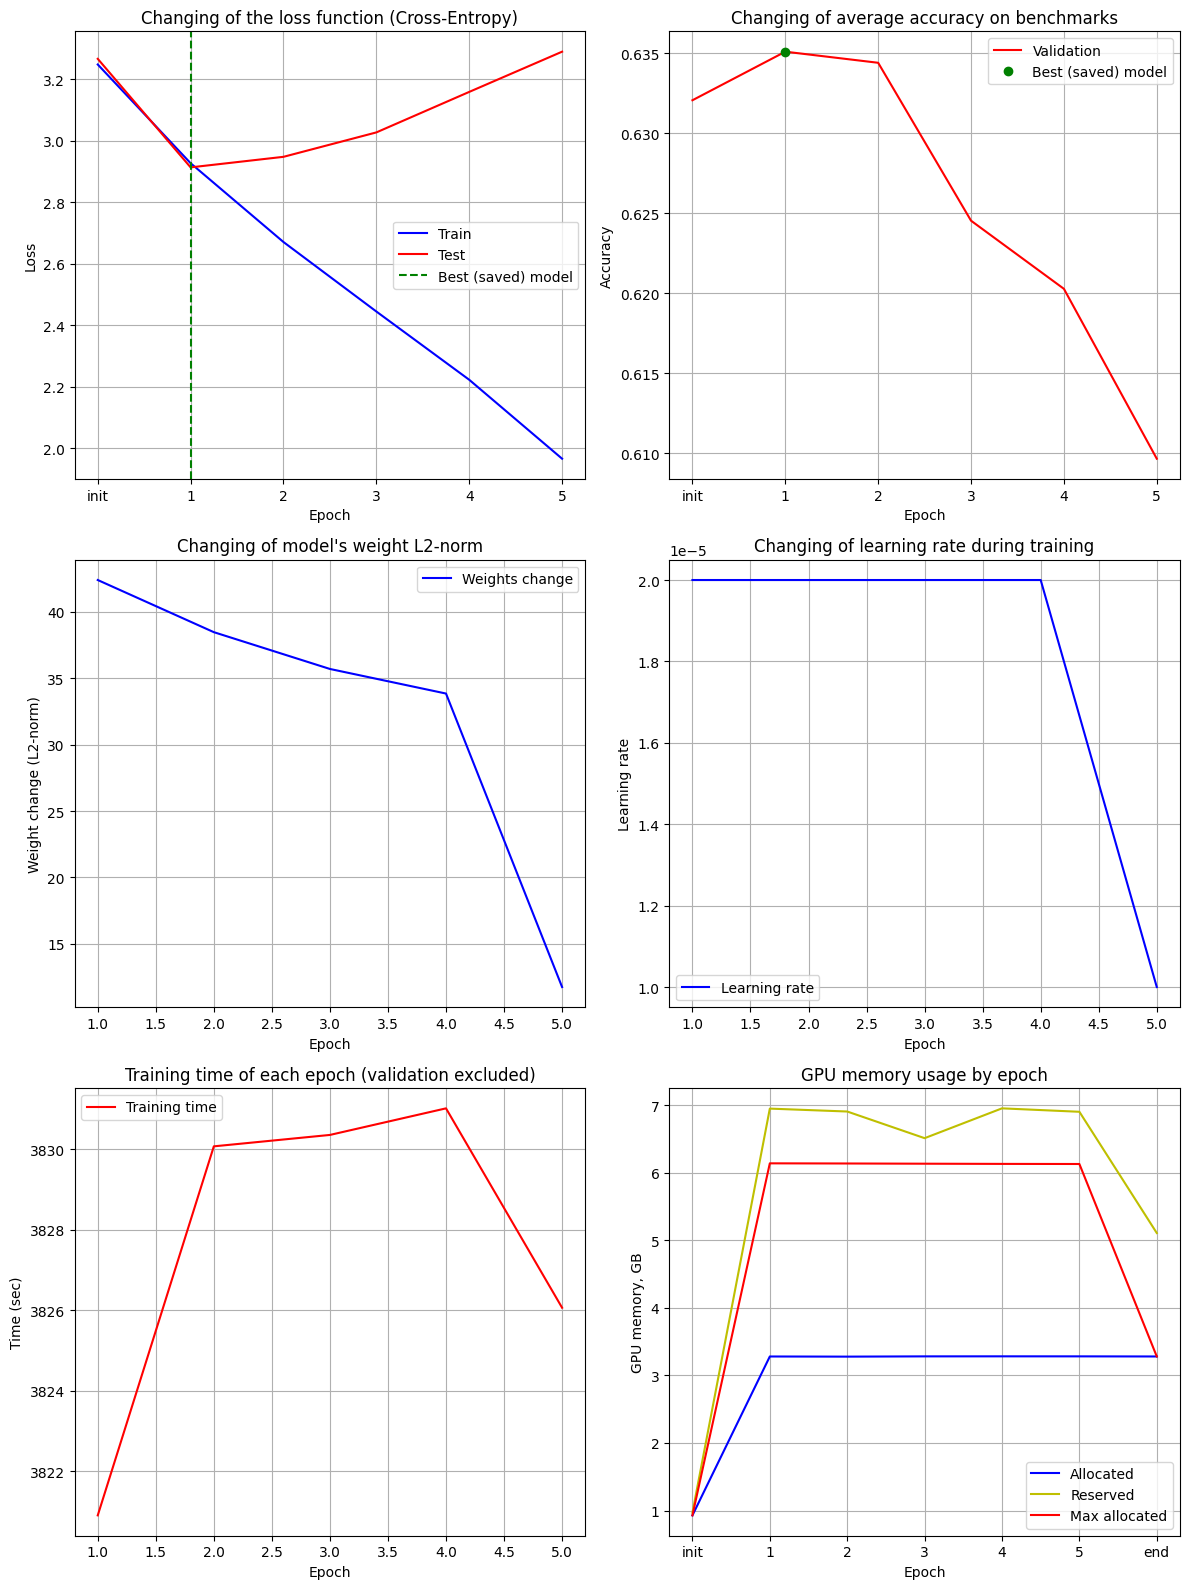

In [ ]:
plot_history(history)

In [ ]:
history["Test benchmarks"] = benchmark_model(f"{MODELS_DIR}{model_name}", EVAL_BENCHMARKS) # тестирование на всех бенчмарках сохранённой (лучшей) модели
save_history(history, model_name) # перезапись сохранённой истории (с результатами валидации)
history["Test benchmarks"]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

Map:   0%|          | 0/39905 [00:00<?, ? examples/s]

Map:   0%|          | 0/10042 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 60566/60566 [1:00:15<00:00, 16.75it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


,arc_challenge,arc_easy,hellaswag,piqa,winogrande
alias,arc_challenge,arc_easy,hellaswag,piqa,winogrande
"acc,none",0.289249,0.654461,0.400119,0.703482,0.566693
"acc_stderr,none",0.01325,0.009758,0.004889,0.010656,0.013927
"acc_norm,none",0.325939,0.625421,0.515435,0.700762,NaN
"acc_norm_stderr,none",0.013697,0.009932,0.004987,0.010684,NaN


## Muon + AdamW

Для эксперимента можно попробовать объединить оба оптимизатора, разделив параметры модели по оптимизаторам.

Подходы к разделению весов между оптимизаторами:
1) Первый вариант — случайным образом поделить веса между оптимизаторами.
2) Второй вариант — учесть, что Muon хорошо работает только с 2D матрицами и передать в него именно такие матрицы, а все остальные веса отправить в AdamW.

In [ ]:
model_name = f"{MODEL_NAME}_Muon_with_AdamW" # название модели для сохранения

In [ ]:
data, model, tokenizer = train_preparation() # загружаем всё необходимое перед обучением

train_dataloader = DataLoader(data["train"], batch_size=BATCH_SIZE, shuffle=True) # DataLoader для итерации в цикле обучения
test_dataloader = DataLoader(data["test"], batch_size=BATCH_SIZE) # DataLoader для итерации в цикле обучения

clear_gpu_cache() # очистка кэша и обновление мониторов памяти

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
# trainable_params = [param for param in model.parameters() if param.requires_grad] # параметры для обучения
# random.shuffle(trainable_params) # случайным образом перемешиваем обучаемые параметры
# muon_params = trainable_params[:len(trainable_params) // 2] # параметры для обучения с помощью Muon оптимизатора
# adamw_params = trainable_params[len(trainable_params) // 2:] # параметры для обучения с помощью AdamW оптимизатора

muon_params = [] # параметры для Muon оптимизатора
adamw_params = [] # параметры для AdamW оптимизатора
for name, param in model.named_parameters(): # идём по параметрам модели
    if (param.ndim == 2) and ("embed" not in name): # условие для матриц весов (только 2d матрицы)
        muon_params.append(param)
    else: # если веса не пойдут в оптимизатор, то они не требуют градиент
        adamw_params.append(param)


optimizer_muon = torch.optim.Muon(
    muon_params, 
    lr=LEARNING_RATE, 
    adjust_lr_fn="match_rms_adamw", # регулировка learning rate для ускорения обучения ("original" или "match_rms_adamw", для чистоты эксперимента выбран "match_rms_adamw", так как иначе веса обновляются очень слабо по сравнению с AdamW при аналогичном lr)
    momentum=0.9, # коэффициент инерции (отвечает за усреднение градиентов, помогает «разгоняться» в нужном направлении и сглаживать резкие колебания и шум; 0.9 означает, что текущий шаг на 90% зависит от предыдущего направления и на 10% от нового градиента) 
    ns_coefficients = (3.4445, -4.775, 2.0315), # коэффициенты полинома ортогонализации Ньютона-Шульца
    ns_steps=5, # количество итераций метода Ньютона-Шульца (чем больше, тем выше точность ортогонализации, но медленнее шаг обучения)
    weight_decay=WEIGHT_DECAY, # коэффициент затухания весов (регуляризация против переобучения)
    eps=1e-07, # число для предотвращения деления на ноль
) # оптимизатор обучения модели

optimizer_adamw = torch.optim.AdamW(
    adamw_params,
    lr=LEARNING_RATE, 
    betas=(0.9, 0.95), # beta1 — Momentum, коэффициент инерции (отвечает за усреднение градиентов, помогает «разгоняться» в нужном направлении и сглаживать резкие колебания; 0.9 означает, что текущий шаг на 90% зависит от предыдущего направления и на 10% от нового градиента), beta2 — RMSProp, адаптивная скорость обучения («нормирует» шаги: если градиент по какому-то весу очень большой и шумный, beta2 помогает уменьшить скорость обучения для этого веса, чтобы обучение не «взорвалось»), то есть beta1 усредняет направление движения, а beta2 — масштаб (интенсивность) этого движения для каждого параметра отдельно
    weight_decay=WEIGHT_DECAY, # коэффициент затухания весов (регуляризация против переобучения)
    eps=1e-08, # число для предотвращения деления на ноль
) # оптимизатор обучения модели

In [ ]:
print_trainable_parameters(model) # обучаемые параметры

trainable params: 494032768 || all params: 494032768 || trainable: 100.0000%


In [ ]:
history = train_model(model, [optimizer_muon, optimizer_adamw], train_dataloader, test_dataloader, model_name, "AVG benchmarks acc") # обучение модели
save_history(history, model_name) # сохранение истории
history

Starting training with hyperparams:
WORKING_DIR: /kaggle/working/
DATA_DIR: /kaggle/working/data/
MODELS_DIR: /kaggle/working/models/
RESULTS_DIR: /kaggle/working/results/
DATASET_NAME: Elriggs/openwebtext-100k
MODEL_NAME: Qwen/Qwen2.5-0.5B
EVAL_BENCHMARKS_TRAINING: ['piqa', 'winogrande']
EVAL_BENCHMARKS: ['piqa', 'arc_easy', 'arc_challenge', 'winogrande', 'hellaswag']
MAX_SAMPLES: 4000
MAX_SEQUENCE_LEN: 256
TEST_SIZE: 0.1
EPOCHS: 20
EPOCHS_PATIENCE: 3
TOLERANCE: 1
LEARNING_RATE: 2e-05
WEIGHT_DECAY: 0.1
SCHEDULER_STEP: 4
SCHEDULER_GAMMA: 0.5
BATCH_SIZE: 4
VERBOSE: 1
RANDOM_STATE: 42
DEVICE: cuda:0


  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration


piqa_train.parquet:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

...

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Running loglikelihood requests: 100%|██████████| 6210/6210 [05:25<00:00, 19.08it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


Epoch [5/20], Average train Loss: 1.9370, Average test Loss: 3.3295, Tracked metric (AVG benchmarks acc): 0.616015, Learning rate: 0.00001000, Weight change: 12.704999.
Early stopping at epoch 5, tracked metric: 0.616015!
Total training time: 22770.40 sec ~ 6.33 hours.


{'Hyperparams': {'WORKING_DIR': '/kaggle/working/',
  'DATA_DIR': '/kaggle/working/data/',
  'MODELS_DIR': '/kaggle/working/models/',
  'RESULTS_DIR': '/kaggle/working/results/',
  'DATASET_NAME': 'Elriggs/openwebtext-100k',
  'MODEL_NAME': 'Qwen/Qwen2.5-0.5B',
  'EVAL_BENCHMARKS_TRAINING': ['piqa', 'winogrande'],
  'EVAL_BENCHMARKS': ['piqa',
   'arc_easy',
   'arc_challenge',
   'winogrande',
   'hellaswag'],
  'MAX_SAMPLES': 4000,
  'MAX_SEQUENCE_LEN': 256,
  'TEST_SIZE': 0.1,
  'EPOCHS': 20,
  'EPOCHS_PATIENCE': 3,
  'TOLERANCE': 1,
  'LEARNING_RATE': 2e-05,
  'WEIGHT_DECAY': 0.1,
  'SCHEDULER_STEP': 4,
  'SCHEDULER_GAMMA': 0.5,
  'BATCH_SIZE': 4,
  'VERBOSE': 1,
  'RANDOM_STATE': 42,
  'DEVICE': device(type='cuda', index=0)},
 'Train loss': {'init': 3.2488166513707903,
  1: 2.937829207579295,
  2: 2.6700033904446494,
  3: 2.4360215559270646,
  4: 2.205583234495587,
  5: 1.9370247042179107},
 'Test loss': {'init': 3.2672068452835084,
  1: 2.932318024635315,
  2: 2.9756984901428223,

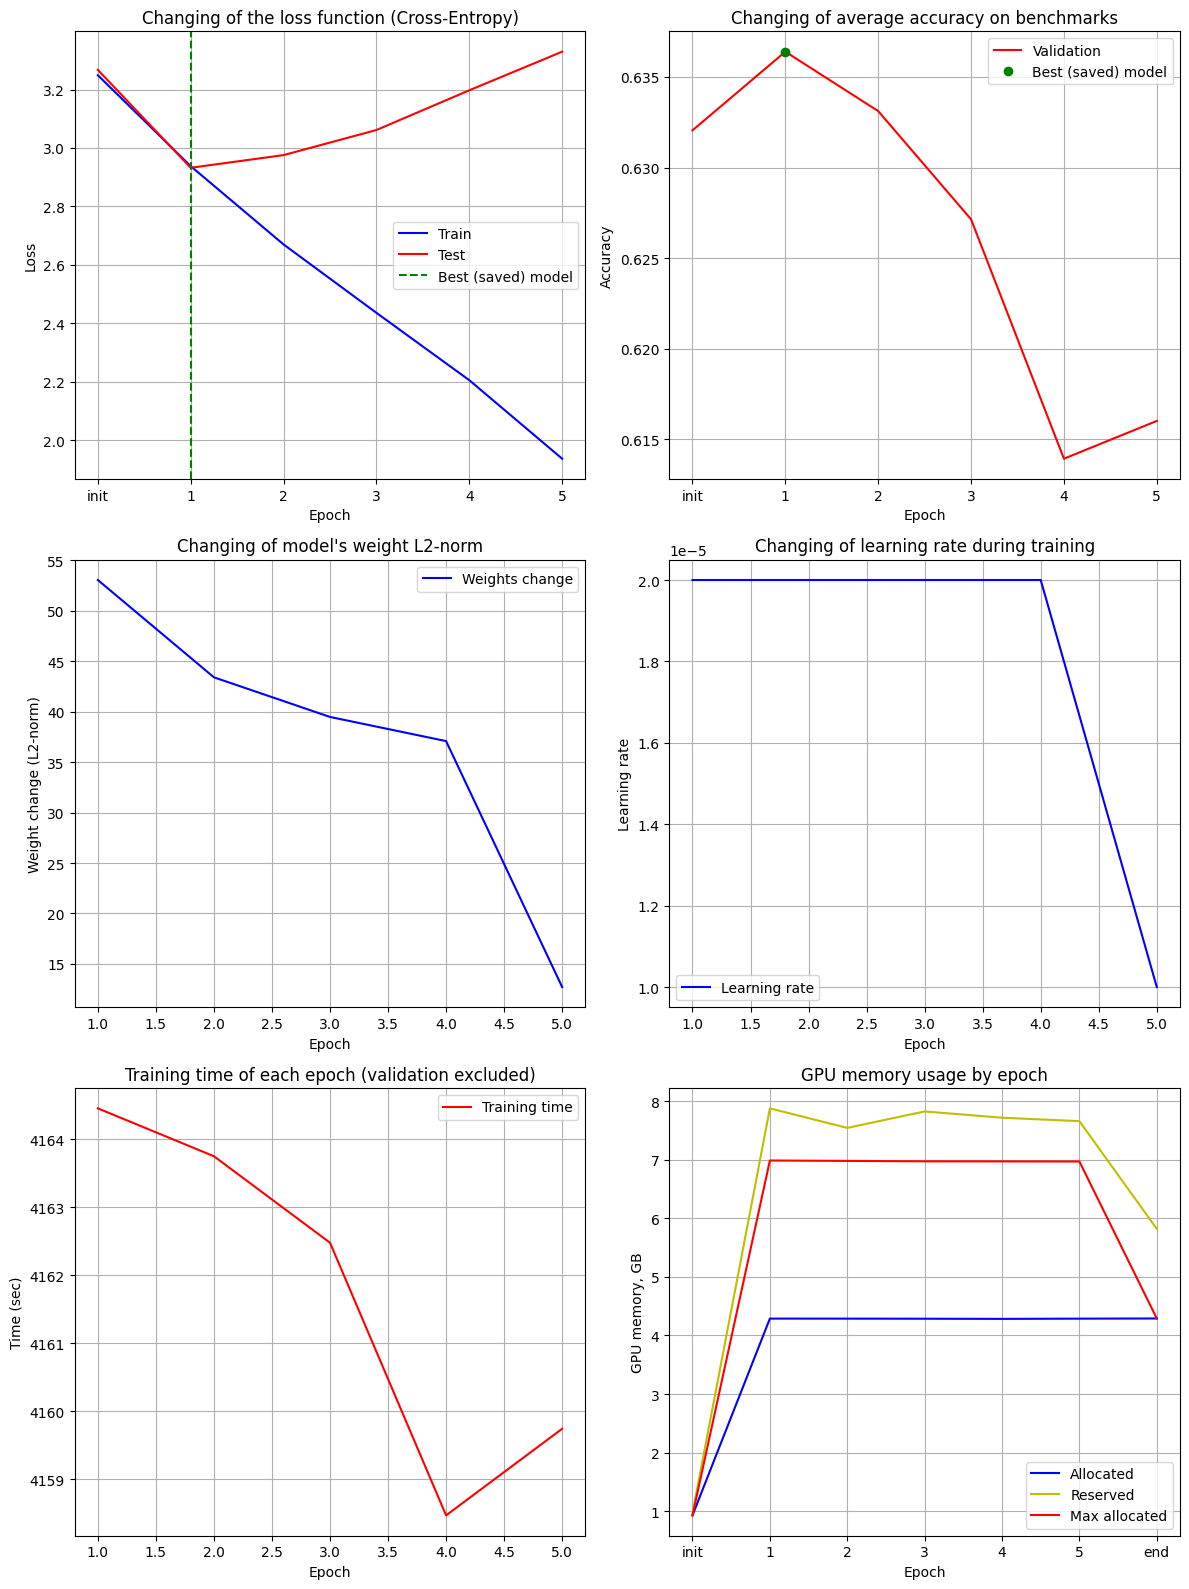

In [ ]:
plot_history(history)

In [ ]:
history["Test benchmarks"] = benchmark_model(f"{MODELS_DIR}{model_name}", EVAL_BENCHMARKS) # тестирование на всех бенчмарках сохранённой (лучшей) модели
save_history(history, model_name) # перезапись сохранённой истории (с результатами валидации)
history["Test benchmarks"]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

Map:   0%|          | 0/39905 [00:00<?, ? examples/s]

Map:   0%|          | 0/10042 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 60566/60566 [1:02:34<00:00, 16.13it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


,arc_challenge,arc_easy,hellaswag,piqa,winogrande
alias,arc_challenge,arc_easy,hellaswag,piqa,winogrande
"acc,none",0.296075,0.661616,0.40002,0.702938,0.56985
"acc_stderr,none",0.013341,0.009709,0.004889,0.010662,0.013915
"acc_norm,none",0.332765,0.639731,0.515037,0.699129,NaN
"acc_norm_stderr,none",0.01377,0.009851,0.004988,0.010701,NaN


# 3) Сравнение результатов

Для корректности сравнения у всех экспериментов по обучению были выставлены следующие гиперпараметры:
* Максимальное количество сэмплов для обучения: 4000
* Размер тестовой выборки: 10%
* Дополнительная валидация при обучении на бенчмарках: "piqa", "winogrande"
* Лимит на количество генерируемых моделью токенов: 256
* Максимальное количество эпох обучения: 20
* Эпох до досрочного прерывания обучения (без улучшения отслеживаемой метрики и/или сходимости весов): 3
* Отслеживаемая метрика для прерывания обучения: средняя точность на бенчмарках
* Изначальный learning rate: $2^{-5}$
* Планировщик обучения, изменяющий learning rate в 0.5 раз каждые 4 эпохи
* Коэффициент L2-регуляризации для предотвращения переобучения: 0.1
* Коэффициент Momentum: 0.9
* Размер батча: 4
* Фиксированный seed случайности: 42

Изменение некоторых из них может повлиять на процесс обучения и сходимости как в лучшую сторону (увеличение размера батча для ускорение Muon, так как он меньше потребляет памяти), так и в худшую (уменьшение learning rate, к которому чувствителен Muon, приведёт к сильному уменьшению шагов изменения весов и, следовательно, к замедлению обновления весов).

## Загрузка логов

In [135]:
for root, dirs, files in os.walk(RESULTS_DIR): # идём по файлам внутри подпапок папки RESULTS_DIR
    for file in files:
        file_path = os.path.join(root, file) # относительный путь до файла
        print(file_path)

./results/Qwen\Qwen2.5-0.5B\history.pkl
./results/Qwen\Qwen2.5-0.5B_AdamW\history.pkl
./results/Qwen\Qwen2.5-0.5B_AdamW_2k\history.pkl
./results/Qwen\Qwen2.5-0.5B_AdamW_8k\history.pkl
./results/Qwen\Qwen2.5-0.5B_Muon\history.pkl
./results/Qwen\Qwen2.5-0.5B_Muon_2k\history.pkl
./results/Qwen\Qwen2.5-0.5B_Muon_with_AdamW\history.pkl
./results/Qwen\Qwen2.5-0.5B_Muon_with_AdamW_2k\history.pkl


In [136]:
def load_history(model_name: str) -> dict:
    """
    Функция для загрузки сохранённой истории обучения.
    Parameters:
        model_name (str) : Название сохранённой модели.
    Returns:
        dict: Словарь с логами процесса обучения и валидации.
    """
    with open(f"{RESULTS_DIR}{model_name}/history.pkl", 'rb') as file: # открытие файла для чтения ('rb' — бинарная)
        return pickle.load(file) # загрузка из файла

Для более компексного анализа был проведён ещё один эксперимент, включающий не 4000 сэмплов, а 8000. Обучение проводилось только для оптимизатора AdamW (*AdamW_8k*), посколько другие оптимизаторы просто не укладывались в квоту Kaggle.

In [145]:
histories = {}
optimizer_names = ["AdamW_8k", "AdamW", "Muon", "Muon_with_AdamW"]
for optimizer_name in optimizer_names: # рассмотренные оптимизаторы
    histories[optimizer_name] = load_history(f"{MODEL_NAME}_{optimizer_name}") # загрузка сохранённых логов

## Сравнение процесса fine-tuning_а 

### Loss и качественные метрики

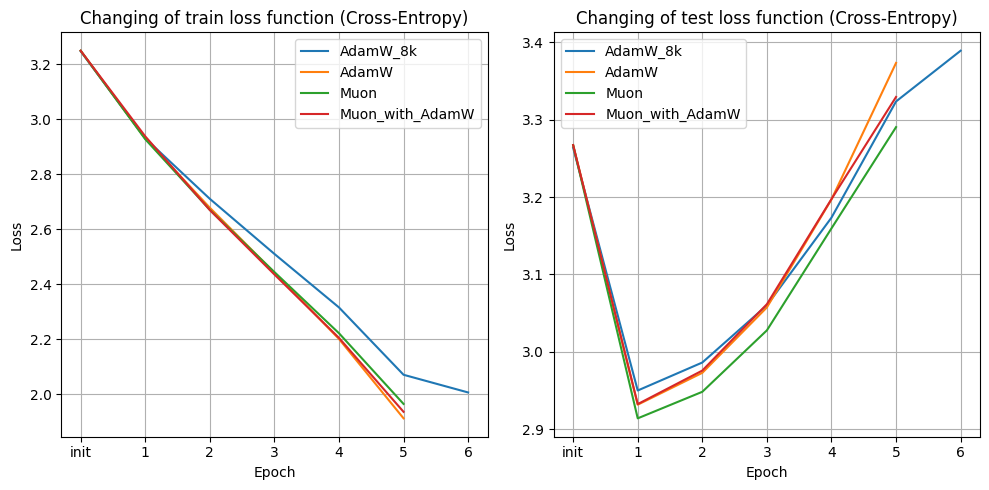

In [146]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    axes[0].plot(histories[optimizer_name]["Train loss"].keys(), histories[optimizer_name]["Train loss"].values(), label=optimizer_name) # построение графика
axes[0].set_title("Changing of train loss function (Cross-Entropy)") # название фигуры
axes[0].set_xlabel("Epoch") # подпись по оси OX
axes[0].set_ylabel("Loss") # подпись по оси OY
axes[0].grid(True) # отображение сетки на графике
axes[0].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    axes[1].plot(histories[optimizer_name]["Test loss"].keys(), histories[optimizer_name]["Test loss"].values(), label=optimizer_name) # построение графика
axes[1].set_title("Changing of test loss function (Cross-Entropy)") # название фигуры
axes[1].set_xlabel("Epoch") # подпись по оси OX
axes[1].set_ylabel("Loss") # подпись по оси OY
axes[1].grid(True) # отображение сетки на графике
axes[1].legend() # отображение подписей графиков

plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
plt.show() # показ фигуры

При обучении с любым оптимизатором (*включая эксперимент AdamW_8k*), **изменение Cross-Entropy loss**, как на обучающих данных, так и на тестовых, ***имеет примерно одинаковый тренд. Быстрое обучение с сильным падением loss, но при этом переобучение после первой же эпохи*** (loss на тестовых данных имеет V-образный тренд). Данное наблюдение можно связать с тем, что модель слишком большая для столь малого количества разрозненных данных (даже увеличение до 8000 сэмплов не решило проблему).

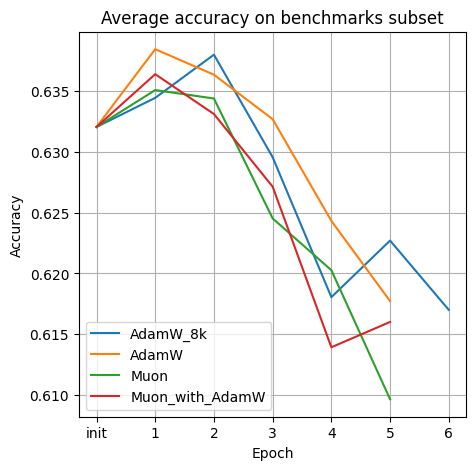

In [147]:
fig, axes = plt.subplots(figsize=(5, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    axes.plot(histories[optimizer_name]["AVG benchmarks acc"].keys(), histories[optimizer_name]["AVG benchmarks acc"].values(), label=optimizer_name) # построение графика
axes.set_title("Average accuracy on benchmarks subset") # название фигуры
axes.set_xlabel("Epoch") # подпись по оси OX
axes.set_ylabel("Accuracy") # подпись по оси OY
axes.grid(True) # отображение сетки на графике
axes.legend() # отображение подписей графиков

plt.show() # показ фигуры

Изменение **отслеживаемой метрики** (*средней точности на подмножестве бенчмарков*) также показывает ***схожий тренд среди всех экспериментов, где метрика улучшается до 1-2 эпохи, после чего идёт резкий спад из-за переобучения***. При этом обучение с AdamW (*AdamW, AdamW_8k, Muon_with_AdamW*) показывает показатели слегка выше, чем при обучении только с оптимизатором Muon (*стоит уточнить, что в Muon обучается лишь 72% весов модели, тогда как в других экспериментах все 100%*). 

### Время обучения и сходимость

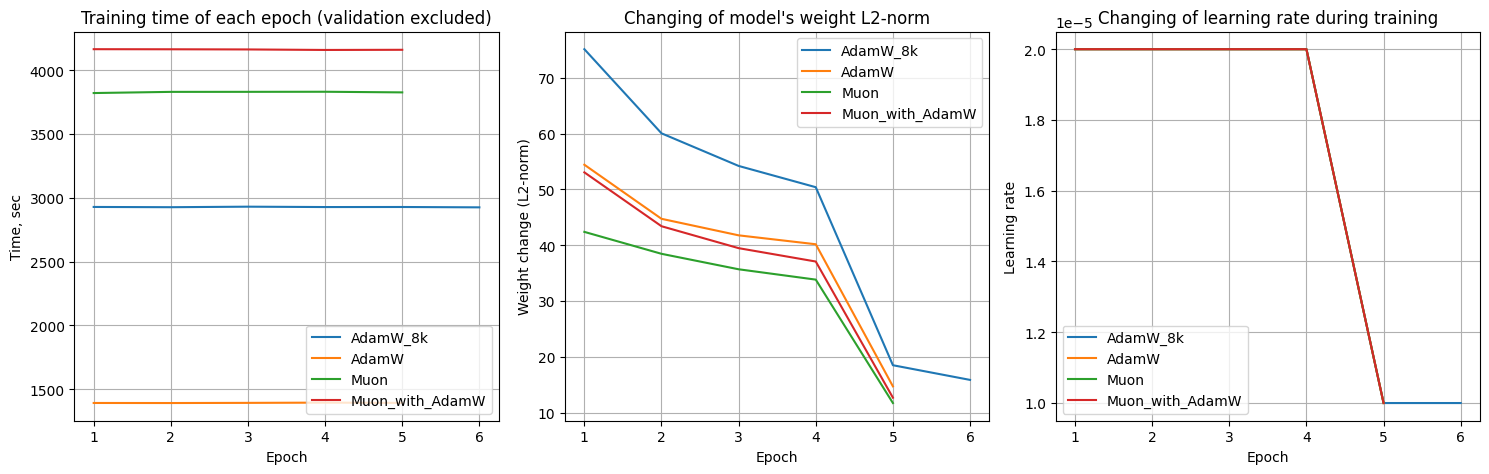

In [148]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    axes[0].plot(histories[optimizer_name]["Time epoch"].keys(), histories[optimizer_name]["Time epoch"].values(), label=optimizer_name) # построение графика
axes[0].set_title("Training time of each epoch (validation excluded)") # название фигуры
axes[0].set_xlabel("Epoch") # подпись по оси OX
axes[0].set_ylabel("Time, sec") # подпись по оси OY
axes[0].grid(True) # отображение сетки на графике
axes[0].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    axes[1].plot(histories[optimizer_name]["Weight convergence"].keys(), histories[optimizer_name]["Weight convergence"].values(), label=optimizer_name) # построение графика
axes[1].set_title("Changing of model's weight L2-norm") # название фигуры
axes[1].set_xlabel("Epoch") # подпись по оси OX
axes[1].set_ylabel("Weight change (L2-norm)") # подпись по оси OY
axes[1].grid(True) # отображение сетки на графике
axes[1].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    axes[2].plot(histories[optimizer_name]["Learning rate"].keys(), histories[optimizer_name]["Learning rate"].values(), label=optimizer_name) # построение графика
axes[2].set_title("Changing of learning rate during training") # название фигуры
axes[2].set_xlabel("Epoch") # подпись по оси OX
axes[2].set_ylabel("Learning rate") # подпись по оси OY
axes[2].grid(True) # отображение сетки на графике
axes[2].legend() # отображение подписей графиков

plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
plt.show() # показ фигуры

**Время обучения** сильно разнится между оптимизаторами, где:
1) ***Быстрее всего обучаются модели с AdamW*** (*даже с увеличенным в два раза объёмом входных данных*), ~1400 секунд на 4000 сэмплов (23 минуты на эпоху) и ~3000 секунд (50 минту на эпоху при 8000 сэмплов). Время обучения чуть ли не линейно зависит от количества данных.
2) Оптимизатор ***Muon*** даже при 4000 сэмплов тратил на одну эпоху ~3800 секунд, что составляет чуть более часа времени и что аж ***почти в три раза хуже***, чем AdamW на тех же данных.
3) ***Muon с AdamW же показали самое долгое обучение*** (~4100 секунд), так как сверху, к оптимизируемым с момощью Muon весам добавлялась оптимизация других весовых матриц с помощью AdamW.

**Изменение весов** при обучении также различается. 
1) ***Меньше всего они изменялись при оптимизации алгоритмом Muon***, при этом значение loss функции было сопоставимо с другими оптимизаторами. То есть для достижения аналогичного "прогресса", Muon_у достаточно изменять веса на меньшее значение (*при этом loss на тестовых данных даже лучше, чем у других оптимизаторов, что нельзя сказать про точность на бенчмарках*). 
2) ***Сильнее всего веса изменялись при обучении с AdamW***, на 25% выраженнее смещение по отношению к Muon.
3) Изменение весов ***при комбинации оптимизаторов оказалось чем-то средним между Muon и AdamW***.

*Также стоит отметить, что чем больше данных, тем сильнее изменялись веса модели (согласно экспериментам с 4000 и 8000 сэмплов).*

Mean epoch time for optimizer AdamW_8k: 2927.87 sec ~ 0.81 hours.
Mean epoch time for optimizer AdamW: 1393.62 sec ~ 0.39 hours.
Mean epoch time for optimizer Muon: 3827.69 sec ~ 1.06 hours.
Mean epoch time for optimizer Muon_with_AdamW: 4161.78 sec ~ 1.16 hours.


C:\Users\User\Documents\TEMP\ipykernel_45736\2732061511.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(axes.get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')


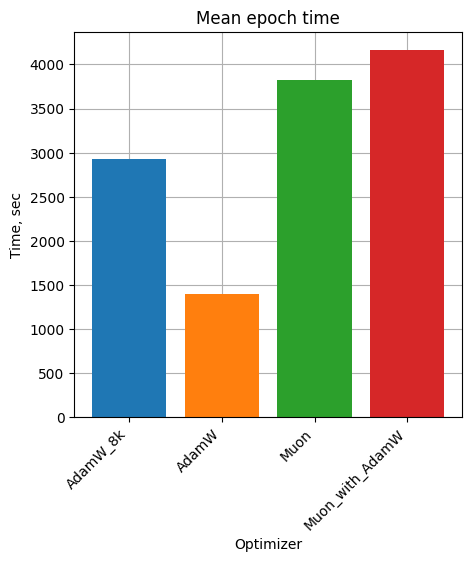

In [155]:
fig, axes = plt.subplots(figsize=(5, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    mean_epoch_time = np.mean(list(histories[optimizer_name]["Time epoch"].values())) # среднее время обучения одной эпохи
    
    axes.bar(optimizer_name, mean_epoch_time, label=optimizer_name) # построение графика
    print(f"Mean epoch time for optimizer {optimizer_name}: {mean_epoch_time:.2f} sec ~ {mean_epoch_time / 60**2:.2f} hours.")
axes.set_xticklabels(axes.get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes.set_title("Mean epoch time") # название фигуры
axes.set_xlabel("Optimizer") # подпись по оси OX
axes.set_ylabel("Time, sec") # подпись по оси OY
axes.grid(True) # отображение сетки на графике
axes.set_axisbelow(True) # перенос сетки на задний план
# axes.legend() # отображение подписей графиков

plt.show() # показ фигуры

C:\Users\User\Documents\TEMP\ipykernel_45736\4200492262.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
C:\Users\User\Documents\TEMP\ipykernel_45736\4200492262.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')


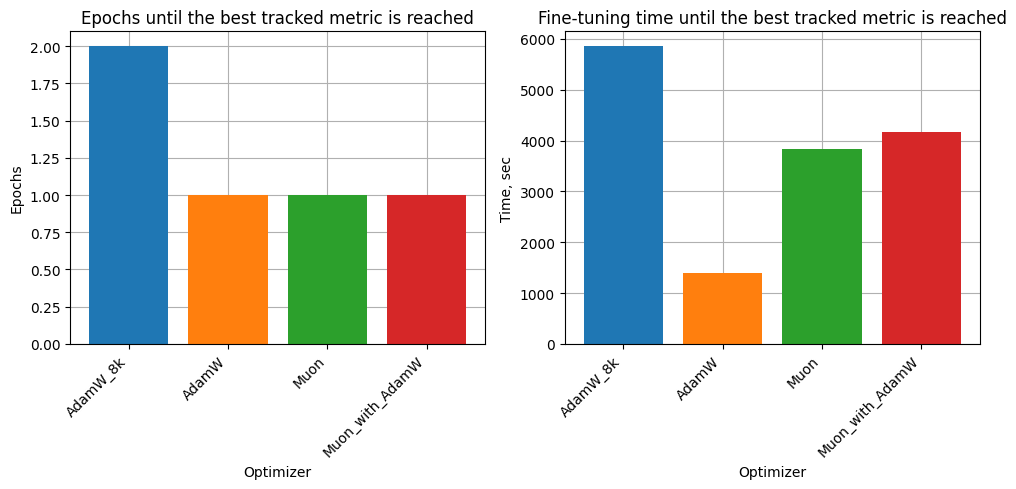

In [159]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    tracked_metric = histories[optimizer_name]["Tracked metric"]

    mean_epoch_time = np.mean(list(histories[optimizer_name]["Time epoch"].values())) # среднее время обучения одной эпохи
    tracked_metric = histories[optimizer_name]["Tracked metric"] # главная отслеживаемая метрика при обучении модели
    metrics = list(histories[optimizer_name][tracked_metric].values())[1:] # значения метрики ([1:] чтобы не учитывать "init" значение, если модель только ухудшалась)
    epochs_to_best_metric = metrics.index(max(metrics)) + 1 # количество эпох обучения до того, как модель получила лучшее значение отслеживаемой метрики 
    axes[0].bar(optimizer_name, epochs_to_best_metric, label=optimizer_name) # построение графика

    axes[1].bar(optimizer_name, epochs_to_best_metric * mean_epoch_time, label=optimizer_name) # построение графика
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes[0].set_title("Epochs until the best tracked metric is reached") # название фигуры
axes[0].set_xlabel("Optimizer") # подпись по оси OX
axes[0].set_ylabel("Epochs") # подпись по оси OY
axes[0].grid(True) # отображение сетки на графике
axes[0].set_axisbelow(True) # перенос сетки на задний план
# axes[0].legend() # отображение подписей графиков

axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes[1].set_title("Fine-tuning time until the best tracked metric is reached") # название фигуры
axes[1].set_xlabel("Optimizer") # подпись по оси OX
axes[1].set_ylabel("Time, sec") # подпись по оси OY
axes[1].grid(True) # отображение сетки на графике
axes[1].set_axisbelow(True) # перенос сетки на задний план
# axes[1].legend() # отображение подписей графиков

plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
plt.show() # показ фигуры

Для того, ***чтобы обучиться до лучшей точности на бенчмарках при 4000 сэмплов, моделям потребовалась всего одна эпоха***. *Если же обучать на большем количестве данных, то вместе с ростом временных затрат на вычисление, метрики также будут выше.*

### Использование памяти GPU

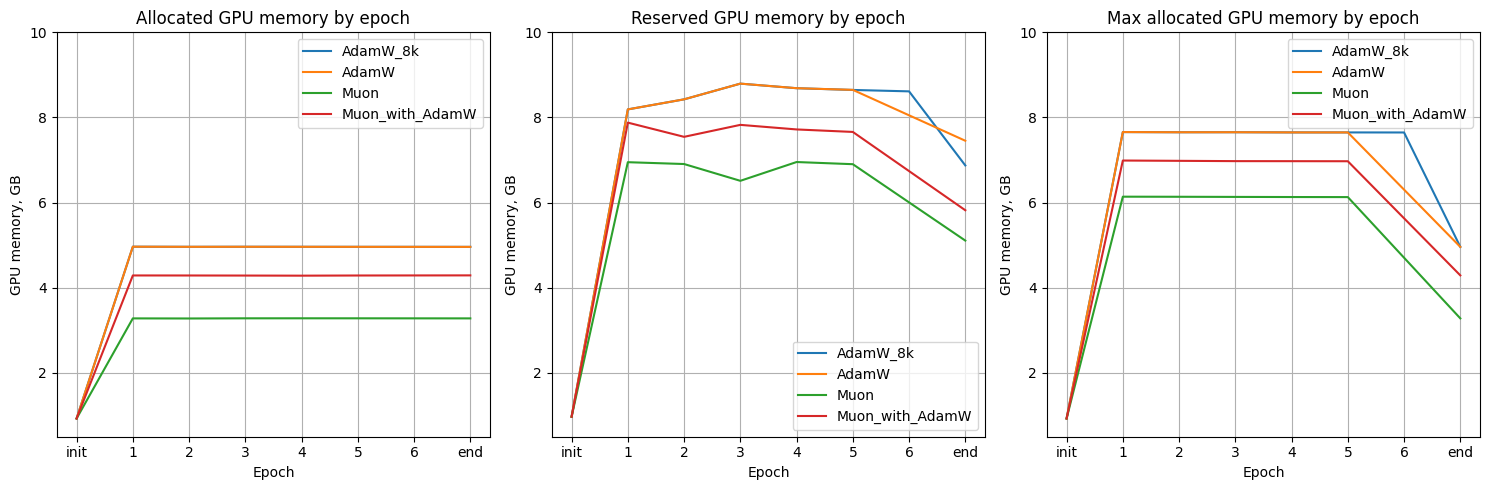

In [151]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    axes[0].plot(histories[optimizer_name]["GPU memory"].keys(), [memory[0] for memory in histories[optimizer_name]["GPU memory"].values()], label=optimizer_name) # построение графика
axes[0].set_title("Allocated GPU memory by epoch") # название фигуры
axes[0].set_xlabel("Epoch") # подпись по оси OX
axes[0].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[0].set_ylim([0.5, 10]) # лимит вывода шкалы
axes[0].grid(True) # отображение сетки на графике
axes[0].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    axes[1].plot(histories[optimizer_name]["GPU memory"].keys(), [memory[1] for memory in histories[optimizer_name]["GPU memory"].values()], label=optimizer_name) # построение графика
axes[1].set_title("Reserved GPU memory by epoch") # название фигуры
axes[1].set_xlabel("Epoch") # подпись по оси OX
axes[1].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[1].set_ylim([0.5, 10]) # лимит вывода шкалы
axes[1].grid(True) # отображение сетки на графике
axes[1].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    axes[2].plot(histories[optimizer_name]["GPU memory"].keys(), [memory[2] for memory in histories[optimizer_name]["GPU memory"].values()], label=optimizer_name) # построение графика
axes[2].set_title("Max allocated GPU memory by epoch") # название фигуры
axes[2].set_xlabel("Epoch") # подпись по оси OX
axes[2].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[2].set_ylim([0.5, 10]) # лимит вывода шкалы
axes[2].grid(True) # отображение сетки на графике
axes[2].legend() # отображение подписей графиков

plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
plt.show() # показ фигуры

Между эпохами использование памяти GPU практически не изменяется (для каждого оптимизатора), поэтому можно перейти к рассмотрению среднего значения.

Mean allocated GPU memory for optimizer AdamW_8k: 4.96 GB.
Mean allocated GPU memory for optimizer AdamW: 4.96 GB.
Mean allocated GPU memory for optimizer Muon: 3.28 GB.
Mean allocated GPU memory for optimizer Muon_with_AdamW: 4.29 GB.
Mean reserved GPU memory for optimizer AdamW_8k: 8.56 GB.
Mean reserved GPU memory for optimizer AdamW: 8.55 GB.
Mean reserved GPU memory for optimizer Muon: 6.84 GB.
Mean reserved GPU memory for optimizer Muon_with_AdamW: 7.73 GB.
Mean max allocated GPU memory for optimizer AdamW_8k: 7.65 GB.
Mean max allocated GPU memory for optimizer AdamW: 7.65 GB.
Mean max allocated GPU memory for optimizer Muon: 6.13 GB.
Mean max allocated GPU memory for optimizer Muon_with_AdamW: 6.98 GB.


C:\Users\User\Documents\TEMP\ipykernel_45736\191600202.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
C:\Users\User\Documents\TEMP\ipykernel_45736\191600202.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
C:\Users\User\Documents\TEMP\ipykernel_45736\191600202.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), ha

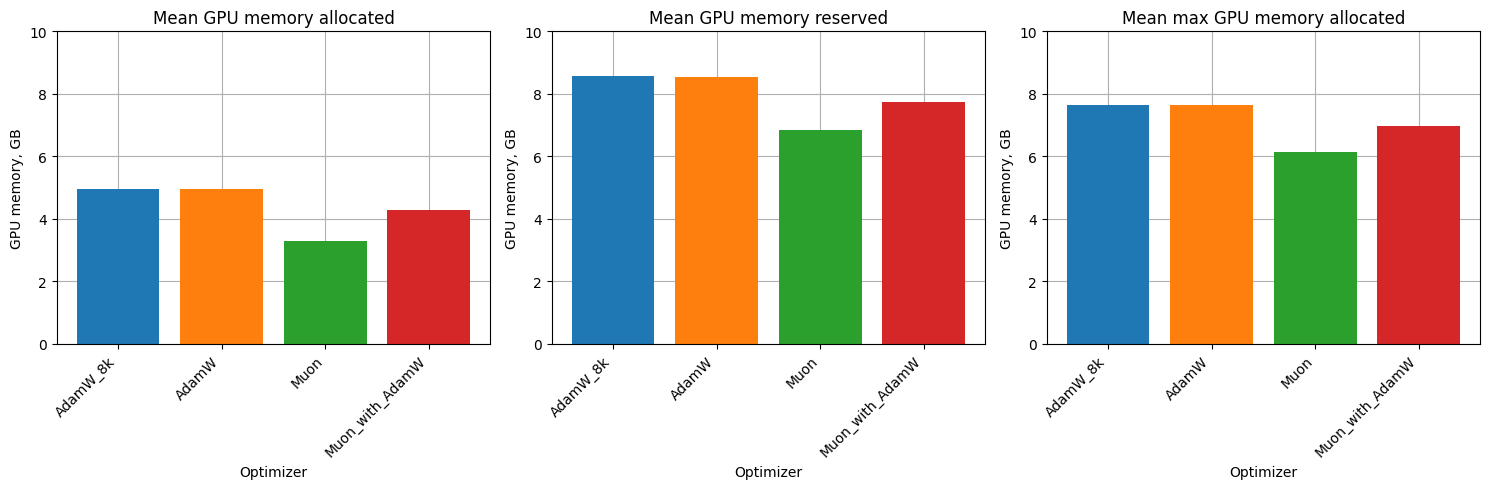

In [160]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5)) # создание фигуры с несколькими подграфиками (ncols и/или nrows) размера figsize

for optimizer_name in optimizer_names:
    mean_allocated_memory = np.mean([memory[0] for memory in histories[optimizer_name]["GPU memory"].values()][1:-1]) # средняя выделяемая память на эпоху обучения
    axes[0].bar(optimizer_name, mean_allocated_memory, label=optimizer_name) # построение графика
    print(f"Mean allocated GPU memory for optimizer {optimizer_name}: {mean_allocated_memory:.2f} GB.")
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes[0].set_title("Mean GPU memory allocated") # название фигуры
axes[0].set_xlabel("Optimizer") # подпись по оси OX
axes[0].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[0].set_ylim([0, 10]) # лимит вывода шкалы
axes[0].grid(True) # отображение сетки на графике
axes[0].set_axisbelow(True) # перенос сетки на задний план
# axes[0].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    mean_reserved_memory = np.mean([memory[1] for memory in histories[optimizer_name]["GPU memory"].values()][1:-1]) # средняя зарезервированная память на эпоху обучения
    axes[1].bar(optimizer_name, mean_reserved_memory, label=optimizer_name) # построение графика
    print(f"Mean reserved GPU memory for optimizer {optimizer_name}: {mean_reserved_memory:.2f} GB.")
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes[1].set_title("Mean GPU memory reserved") # название фигуры
axes[1].set_xlabel("Optimizer") # подпись по оси OX
axes[1].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[1].set_ylim([0, 10]) # лимит вывода шкалы
axes[1].grid(True) # отображение сетки на графике
axes[1].set_axisbelow(True) # перенос сетки на задний план
# axes[1].legend() # отображение подписей графиков

for optimizer_name in optimizer_names:
    mean_max_allocated_memory = np.mean([memory[2] for memory in histories[optimizer_name]["GPU memory"].values()][1:-1]) # средняя максимальная выделенная память на эпоху обучения
    axes[2].bar(optimizer_name, mean_max_allocated_memory, label=optimizer_name) # построение графика
    print(f"Mean max allocated GPU memory for optimizer {optimizer_name}: {mean_max_allocated_memory:.2f} GB.")
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right', rotation=45) # добавление rotation для существующих xticks (get_xticklabels) с выравниванием по правому концу (ha='right')
axes[2].set_title("Mean max GPU memory allocated") # название фигуры
axes[2].set_xlabel("Optimizer") # подпись по оси OX
axes[2].set_ylabel("GPU memory, GB") # подпись по оси OY
axes[2].set_ylim([0, 10]) # лимит вывода шкалы
axes[2].grid(True) # отображение сетки на графике
axes[2].set_axisbelow(True) # перенос сетки на задний план
# axes[2].legend() # отображение подписей графиков

plt.tight_layout() # расположение фигур без наложения друг на друга осей или заголовков
plt.show() # показ фигуры

Использование памяти зависит только от типа оптимизатора и не зависит от размера выборки (так как в один момент грузится лишь батч фиксированного размера, а не весь датасет).

Выделенная GPU память после эпохи:
* ***Наивысшая для AdamW оптимизатора***, так как он для обучаемых весов хранит сразу два момента (скользящее среднее градиентов и скользящее среднее квадратов градиентов). Занимает 3.28 GB вместе с моделью.
* После эпохи обучения ***Muon освобождает больше памяти***, примерно на 33%, по сравнению с AdamW. Занимая лишь 3.28 GB вместе с моделью.
* ***Комбинация Muon и AdamW имеет средние показатели*** (4.29 GB), после обучения они занимают на 15% меньше памяти, по сравнению с AdamW, и на 30% больше, если сравнивать с одним лишь Muon.

Зарезервировання (закэшированная) GPU память:
* Аналогично, больше всего памяти резервирует AdamW оптимизатор, 8.55 GB.
* Один Muon резервирует на 20% меньше памяти (6.84 GB).
* Комбинация оптимизаторов опять имеет промежуточное значение (7.73 GB), на 10% меньшем, чем AdamW, но на 13% больше, чем Muon.

**Максимальная выделенная GPU память во время обучения эпохи**:
* ***Самая высокая у AdamW***, 7.65 GB.
* ***Muon при обучении потребляет на 20% меньше памяти*** (6.13 GB), чем у AdamW.
* Комбинация оптимизаторов потребляет 6.98 GB, что на 9% меньше и на 14% больше, чем AdamW и Muon соответственно.

## Сравнение качества полученных моделей

Валидационные данные — это следующие датасеты, оценивающие понимание модели физических свойств и логических связей между объектами, а также возможности рассуждения на основе здравого смысла (commonsense reasoning):
1) [PIQA](https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks/piqa) (Physical Interaction: Question Answering) — бенчмарк для определения, насколько хорошо языковая модель понимает физические свойства объектов (*хрупкость, твердость*) и повседневные действия (*как лучше помыть посуду или закрепить предмет*). 
В датасете бенчмарка есть 4 поля:
    * goal — описание цели или вопроса;
    * sol1 — первый вариант решения;
    * sol2 — второй вариант решения;
    * label — индекс верного ответа (0 — для sol1, 1 — для sol2).
2) [ARC easy](https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks/arc) (AI2 Reasoning Easy) — бенчмарк, созданный для оценки способности систем искусственного интеллекта отвечать на вопросы, требующие элементарных научных знаний и логики. Набор состоит из вопросов с множественным выбором (multiple-choice), взятых из реальных школьных экзаменов по естественным наукам (3–9 классы). В категорию «Easy» попали вопросы, на которые современные (на момент создания) модели могли ответить, используя простые статистические методы или поиск по ключевым словам.
В датасете бенчмарка есть 4 поля:
    * id — идентификатор, откуда взят вопрос;
    * question — вопрос;
    * choices — словарь с возможными ответами;
    * answerKey — ключ правильного ответа.
3) [ARC challenge](https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks/arc) (AI2 Reasoning Challenge) — по структуре аналогичен "ARC easy", но содержит более тяжёлые вопросы, для ответа на которые требуется «многоходовое» рассуждение.
4) [WinoGrande](https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks/winogrande) — бенчмарк, предназначенный для оценки способности моделей искусственного интеллекта к рассуждению на основе здравого смысла (commonsense reasoning). Бенчмарк основан на задачах типа Winograd Schema Challenge (WSC), где модели нужно правильно соотнести местоимение с одним из двух упомянутых в предложении объектов. 
В датасете бенчмарка есть 4 поля:
    * sentence — описание цели или вопроса;
    * option1 — первый вариант решения;
    * option2 — второй вариант решения;
    * answer — индекс верного ответа (1 — для option1, 2 — для option2).

    Например, имеется выражение «Трофей не поместился в коричневый чемодан, потому что *** был слишком большим». Модели нужно выбрать правильный ответ из предложенных. Варианты: А) Трофей; Б) Чемодан. Правильный ответ: А (Трофей).
5) [HellaSwag](https://github.com/EleutherAI/lm-evaluation-harness/tree/main/lm_eval/tasks/hellaswag) (Harder Entities, Longer Contexts, and Better Adversarial Filtering) — бенчмарк, созданный для оценки способностей больших языковых моделей (LLM) к здравомыслию (commonsense reasoning). Бенчмарк проверяет, насколько хорошо модель может предсказать наиболее логичное завершение повседневного сценария. В отличие от простых тестов, HellaSwag использует метод состязательной фильтрации (Adversarial Filtering): варианты ответов генерируются так, чтобы они выглядели правдоподобно для алгоритмов, но были очевидно неверными для человека. Модели предлагается контекст (например, описание начала видеоролика) и четыре варианта продолжения. Задача — выбрать один правильный. Задания подобраны так, что они легки для людей (точность ~95%), но долгое время оставались крайне сложными для ИИ.


Основной метрикой всех бенчмарков является **Accuracy**, то есть сравниваются предсказанные моделью индексы правильных ответов (0, 1, ...) с истинной меткой label. Чем выше Accuracy, тем лучше модель понимает суть предложения. Для этого с помощью CausalLM модели строится оценка логарифмической вероятности (log-likelihood) каждого из вариантов ответа. Модель «выбирает» тот вариант, вероятность генерации которого выше при заданном контексте (входе).

In [38]:
baseline = benchmark_model(MODEL_NAME, EVAL_BENCHMARKS) # тестирование на всех бенчмарках стандартной модели
save_history(baseline, MODEL_NAME) # сохранение истории
baseline

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration


piqa_train.parquet:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

piqa_validation.parquet:   0%|          | 0.00/300k [00:00<?, ?B/s]

piqa_test.parquet:   0%|          | 0.00/496k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

Map:   0%|          | 0/39905 [00:00<?, ? examples/s]

Map:   0%|          | 0/10042 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 60566/60566 [1:01:05<00:00, 16.52it/s]
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


,arc_challenge,arc_easy,hellaswag,piqa,winogrande
alias,arc_challenge,arc_easy,hellaswag,piqa,winogrande
"acc,none",0.292662,0.646465,0.406094,0.702938,0.561168
"acc_stderr,none",0.013296,0.00981,0.004901,0.010662,0.013947
"acc_norm,none",0.321672,0.587542,0.52141,0.702394,NaN
"acc_norm_stderr,none",0.01365,0.010101,0.004985,0.010667,NaN


In [153]:
histories["Baseline"] = load_history(MODEL_NAME) 

In [154]:
metrics_comparison = histories["Baseline"].loc["acc,none"].to_frame() # берём строку DataFrame_а с accuracy и конвертируем её в новый DataFrame (столбец)
metrics_comparison.rename(columns={"acc,none": "Baseline"}, inplace=True) # переименовываем колонку, что ранее соответствовала индексу строки

for optimizer_name in optimizer_names:
    metrics_comparison[optimizer_name] = histories[optimizer_name]["Test benchmarks"].loc["acc,none"] # добавляем новые столбцы с accuracy, соответствующие рассмотренным оптимизаторам

metrics_comparison = metrics_comparison.astype(float) # приведение к типу float столбцов (для отображения градиента)
metrics_comparison.style.background_gradient(cmap='RdYlGn', axis=1) # градиентная заливка строк в зависимости от значения (не отображается в VS Code)

,Baseline,AdamW_8k,AdamW,Muon,Muon_with_AdamW
arc_challenge,0.292662,0.302048,0.298635,0.289249,0.296075
arc_easy,0.646465,0.658670,0.659512,0.654461,0.661616
hellaswag,0.406094,0.413264,0.401514,0.400119,0.400020
piqa,0.702938,0.704570,0.707835,0.703482,0.702938
winogrande,0.561168,0.571429,0.569061,0.566693,0.569850


Сравнивая **Accuracy на бенчмарка**х видно, что:
* ***Лучшие метрики, как и ожидалось, показал эксперимент с наибольшим количеством сэмплов*** (8000 против 4000 у всех остальных оптимизаторов). Он обошёл "baseline" (модель без fine-tuning_а) по всем бенчмаркам на значение 0.2 — 1.2% точности. 
* ***Второе место по Accuracy занимает AdamW***, обученный на 4000 сэмплов. Он даже сумел слегка (на ~0.001 — 0.003, что менее половины процента) обогнать AdamW на бенчмарках "arc_easy" и "piqa".
* ***Комбинация оптимизаторов показала самые нестабильные метрики***, для бенчмарков "arc_easy" и "winogrande" есть сравнительно неплохой прирост Accuracy, тогда как на "hellaswag" и "piqa" модель справилась хуже, чем её необученная версия.
* Один ***Muon показал самые худшие результаты***, в двух бенчмарках он оказался хуже необученной модели ("arc_challenge" и "hellaswag"), а в трёх других лишь слегка лучше ("arc_easy", "piqa", "winogrande").

# 4) Заключение

**Основные выводы**:
* ***На финальное качество модели больше влияет объем данных, чем тип оптимизатора*** (*хотя fune-tuning с Muon практически не показал улучшения Accuracy*).
* ***Сходимость моделей по loss функции для оптимизаторов практически одинаковая***, но по L2 норме обновления весов модели — нет, сильнее всего они изменяются с AdamW оптимизатором, слабее всего с Muon (*при этом loss у них практически одинаковый*).
* На данный момент ***Muon работает значительно медленнее*** (*в 3 раза*), чем AdamW (*хотя это может быть связано с особенностями архитектуры модели*).
* ***Muon требует меньше памяти*** (*на ~20% по сравнению с AdamW*), так как хранит лишь одну дополнительную матрицу для весов (Momentum).
* Для Muon имеются перспективы, связанные с увеличением размера батча и learning rate.
* ***Комбинация оптимизаторов показывает промежуточные результаты*** при всём анализе, кроме времени обучения, там обучение шло дольше всего.


**Возможности для дальнейшего исследования**: 
* Использование оптимизатора MeZO;
* Обучение на большей части датасета;
* Использование модели, для которой проведение ортогонализации матриц было бы выгоднее и быстрее, чем подсчёт градиентов;
* Увеличение learning rate и размера батча.

# *) Проверка code style 

In [ ]:
# !nbqa pylint task_ru.ipynb

In [ ]:
# !nbqa mypy task_ru.ipynb